# Extensión interseccional: atributo sensible compuesto

posiblemente compuesto por varios atributos y el conjunto de grupos como todas sus
combinaciones, y que el panel principal solo ejercita en el caso de dos grupos.

**Toda la configuración es la del panel principal.** Mismo parámetro de exigencia, mismo
operador, mismos umbrales, misma composición de la disparidad agregada, mismas intensidades
por conjunto y mismo esquema por bloques. La única diferencia es el atributo sensible. Esto
es deliberado: cualquier diferencia observada debe ser atribuible al cambio de atributo y no
a la configuración.

**Qué se espera comprobar.**

1. Que el motor opera correctamente con más de dos grupos.
2. Que la disparidad agregada deja de ser invariante al grupo, cosa que con dos grupos no
   ocurría por la antisimetría de sus componentes.
3. Si Fair-MAD mejora su posición relativa frente a Fair-GAD, ya que su paso de peor caso
   entre grupos deja de seleccionar un máximo sobre valores idénticos. Es la comprobación


In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lamda.experiments import runner, reporting
from lamda.experiments import config as cfg
from lamda.fairness.disparity import FairnessThresholds, FairnessWeights

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# Directorios propios: no se toca nada del panel principal.
RESULTADOS_INT = os.path.join(cfg.RESULTS_DIR, "interseccional")
FIGURAS_INT = os.path.join(RESULTADOS_INT, "figuras")
os.makedirs(FIGURAS_INT, exist_ok=True)
print("Resultados de esta extensión en:", RESULTADOS_INT)

Resultados de esta extensión en: resultados/interseccional


## Panel de la extensión

El modo interseccional se pasa al motor mediante el parámetro `sensitive_mode`, que ya
contemplan tanto `load_and_split` como `run_detection` y `run_mitigation`. No se modifica
`config.py` ni ningún cargador.

In [2]:
# =========================================================
# 1. PANEL DE LA EXTENSIÓN
# =========================================================
# Conjunto y modo interseccional. El modo marginal es el del panel principal y
# se emplea solo para la comparación final, leyendo sus resultados de disco.
PANEL_INT = {
    "adult":  {"modo": "sex_race", "modo_marginal": "sex"},
    "compas": {"modo": "sex_race", "modo_marginal": "race"},
}

def modo_de(dataset):
    """Modo interseccional aplicable a un conjunto de la extensión."""
    return PANEL_INT[dataset]["modo"]

# =========================================================
# 2. MODELO BASE Y UMBRALES (idénticos al panel principal)
# =========================================================
ALPHA = 0.65
OPERATOR = "minmax"
THRESHOLDS = FairnessThresholds(spd=0.1, eod=0.1, di=0.8)

# =========================================================
# 3. COMPOSICIÓN DE LA DISPARIDAD AGREGADA
# =========================================================
NORMALIZAR_DISPARIDAD = True
CLASS_AGGREGATION = "mean"

# Los dos conjuntos son binarios: participan las tres métricas.
COMPOSICION_POR_DATASET = {
    "adult":  {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "compas": {"spd": 1.0, "eod": 1.0, "di": 1.0},
}

def pesos_de(dataset):
    """Pesos de composición de la disparidad agregada de un conjunto."""
    comp = COMPOSICION_POR_DATASET[dataset]
    return FairnessWeights(spd=comp["spd"], eod=comp["eod"], di=comp["di"],
                           normalize=NORMALIZAR_DISPARIDAD)

def descripcion_composicion(dataset):
    """Etiqueta legible de la composición, para trazabilidad en las tablas."""
    w = pesos_de(dataset)
    activas = [n for n, v in (("SPD", w.spd), ("EOD", w.eod), ("DI", w.di)) if v > 0]
    return " + ".join(activas) + (" (normalizada)" if w.normalize else " (sin normalizar)")

EXCLUIR_ATRIBUTO_SENSIBLE = False
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [3]:
# =========================================================
# 4. INTENSIDADES Y ESQUEMA POR BLOQUES (idénticos al panel)
# =========================================================
# Se conservan las intensidades seleccionadas por el criterio de calibración
# sobre el atributo marginal. No se recalibran: el objeto de la extensión es
# aislar el efecto del cambio de atributo sensible, no volver a optimizar.
TAU_J = 0.0
LAMBDA_POR_DATASET = {"adult": 0.2, "compas": 0.3}
ETA_POR_DATASET = {"adult": 5, "compas": 5}
MODO_MAD_POR_DATASET = {"adult": "symmetric", "compas": "symmetric"}
MODO_DISPARIDAD_GAD = "directional"

def lambda_de(d): return LAMBDA_POR_DATASET[d]
def eta_de(d): return ETA_POR_DATASET[d]
def modo_mad_de(d): return MODO_MAD_POR_DATASET[d]

BLOQUES_OBJETIVO = 20
TAMANO_BLOQUE_MINIMO = 32
MODO_SOPORTES = "auto"
UPDATE_EVERY_N_BLOCKS = 1
USE_CUMULATIVE_HISTORY = True
DEFAULT_GROUP_DISPARITY = 0.0

In [4]:
# =========================================================
# 5. DERIVACIÓN DEL ESQUEMA POR BLOQUES
# =========================================================
# El tamaño de bloque y los soportes mínimos dependen del tamaño del conjunto y
# del número de clases, no del número de grupos, de modo que coinciden con los
# del panel principal. Se añaden columnas de diagnóstico con los soportes
# reales del atributo compuesto, para valorar si el filtro llega a activarse.
CONFIG_BLOQUES = {}
diag = []
for name in PANEL_INT:
    Xtr, Xte, ytr, yte, str_, ste, *_ = runner.load_and_split(
        name, sensitive_mode=modo_de(name), test_size=TEST_SIZE,
        random_state=RANDOM_STATE, drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

    n_train = len(Xtr)
    n_clases = int(len(np.unique(ytr)))
    bs = cfg.tamano_bloque(n_train, BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
    mg, mp = cfg.soportes_minimos(n_train, n_classes=n_clases,
                                  block_size=bs, modo=MODO_SOPORTES)
    CONFIG_BLOQUES[name] = {"block_size": bs, "min_group": mg, "min_pos": mp,
                            "U": UPDATE_EVERY_N_BLOCKS, "n_train": n_train,
                            "n_clases": n_clases,
                            "n_bloques": int(np.ceil(n_train / bs))}

    s_tr, y_tr = np.asarray(str_), np.asarray(ytr)
    grupos = sorted(set(s_tr))
    menor_grupo = min((s_tr == g).sum() for g in grupos)
    menor_par = min(((s_tr == g) & (y_tr == c)).sum()
                    for g in grupos for c in np.unique(y_tr))
    diag.append({
        "Dataset": cfg.DATASETS[name].display_name,
        "Modo": modo_de(name), "Grupos": len(grupos),
        "n_train": n_train, "Tamaño de bloque": bs,
        "Nº de bloques": CONFIG_BLOQUES[name]["n_bloques"],
        "Soporte grupo exigido": mg, "Grupo menor en train": int(menor_grupo),
        "Soporte grupo-clase exigido": mp, "Par menor en train": int(menor_par),
        "lambda": lambda_de(name), "eta": eta_de(name),
        "Composición": descripcion_composicion(name),
    })

def parametros_bloques(dataset):
    """Parámetros del esquema por bloques que consume el motor."""
    c = CONFIG_BLOQUES[dataset]
    return dict(block_size=c["block_size"], min_group_size=c["min_group"],
                min_positive_size=c["min_pos"], update_every_n_blocks=c["U"])

config_int = pd.DataFrame(diag).set_index("Dataset")
config_int.to_csv(os.path.join(RESULTADOS_INT, "configuracion_interseccional.csv"))
config_int

,Modo,Grupos,n_train,Tamaño de bloque,Nº de bloques,Soporte grupo exigido,Grupo menor en train,Soporte grupo-clase exigido,Par menor en train,lambda,eta,Composición
Dataset,,,,,,,,,,,,
Adult,sex_race,4,24111,1206,20,50,1486,25,112,0.2000,5,SPD + EOD + DI (normalizada)
COMPAS,sex_race,4,4222,212,20,50,379,25,143,0.3000,5,SPD + EOD + DI (normalizada)


## Comprobación previa: el motor con más de dos grupos

Antes de mitigar conviene verificar dos cosas sobre el modelo clásico. La primera, que el
informe por grupo devuelve cuatro filas y no dos. La segunda, y es la relevante para el
grupos tomaba el mismo valor en ambos por la antisimetría de sus componentes, y esa
invariancia es la que hace vacío el paso de peor caso entre grupos de Fair-MAD.

In [5]:
deteccion_int = {}
for name in PANEL_INT:
    res = runner.run_detection(
        dataset_name=name, sensitive_mode=modo_de(name),
        alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
        weights=pesos_de(name), class_aggregation=CLASS_AGGREGATION,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
        test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    deteccion_int[name] = res
    print(f"[{name}] detección completada | modo={modo_de(name)}")

display(pd.concat(
    {cfg.DATASETS[n].display_name: r.detection_table for n, r in deteccion_int.items()},
    names=["Dataset", "Modelo"]))

[adult] detección completada | modo=sex_race
[compas] detección completada | modo=sex_race


,,n,Accuracy,F1_macro,F1_weighted,F1_binary,mean_disparity,max_disparity,mean_abs_spd,max_abs_spd,mean_abs_eod,max_abs_eod,mean_di,min_di
Dataset,Modelo,,,,,,,,,,,,,
Adult,LAMDA clásico,6028,0.7654,0.7127,0.7745,0.5897,0.0607,0.0862,0.1462,0.1889,0.0994,0.2210,1.0138,0.5084
COMPAS,LAMDA clásico,1056,0.6117,0.5985,0.6028,0.6715,0.3036,0.3813,0.3562,0.4546,0.3528,0.4935,1.2808,0.0253


In [6]:
# Detalle por grupo y clase, con los soportes de test de cada fila.
detalles_int = {}
for name, res in deteccion_int.items():
    y_true = res.predictions["y_test"]
    y_pred = res.predictions["classic"]
    s = res.predictions["sensitive_test"]

    det = reporting.flatten_group_class_report(
        reporting.compute_group_class_fairness(
            y_true, y_pred, s, thresholds=THRESHOLDS, weights=pesos_de(name)))
    det = det.merge(reporting.compute_normal_di_df(y_true, y_pred, s),
                    on=["group", "target_class"], how="left")

    s_arr, y_arr = np.asarray(s), np.asarray(y_true)
    det["n_grupo"] = [int((s_arr == g).sum()) for g in det["group"]]
    det["n_grupo_clase"] = [int(((s_arr == g) & (y_arr == c)).sum())
                            for g, c in zip(det["group"], det["target_class"])]
    det = det[["group", "target_class", "n_grupo", "n_grupo_clase",
               "spd", "eod", "di", "disparity"]].round(4)
    det.to_csv(os.path.join(RESULTADOS_INT, f"{name}_detalle_grupo_clase.csv"), index=False)
    detalles_int[name] = det

    print(f"\n=== {cfg.DATASETS[name].display_name} | modo {modo_de(name)} ===")
    display(det)

    # Disparidad agregada por grupo: promedio sobre las clases.
    por_grupo = det.groupby("group")["disparity"].mean().round(6)
    display(por_grupo.rename("Disparidad agregada del grupo"))
    difiere = por_grupo.nunique() > 1
    print("¿La disparidad agregada difiere entre grupos?:", difiere)
    if not difiere:
        print("AVISO: sigue siendo invariante. Con cuatro grupos no debería serlo; "
              "revisar que el modo interseccional se haya aplicado realmente.")


=== Adult | modo sex_race ===


,group,target_class,n_grupo,n_grupo_clase,spd,eod,di,disparity
0,Female_NonWhite,0,401,372,0.1640,0.0713,1.2461,0.0213
1,Female_NonWhite,1,401,29,-0.1640,-0.1276,0.5084,0.1278
2,Female_White,0,1555,1353,0.1549,0.0882,1.2430,0.0183
3,Female_White,1,1555,202,-0.1549,-0.0442,0.5728,0.0940
4,Male_NonWhite,0,477,373,0.0772,0.0162,1.1150,0.0000
5,Male_NonWhite,1,477,104,-0.0772,-0.2210,0.7652,0.0520
6,Male_White,0,3595,2429,-0.1889,-0.1009,0.7609,0.0429
7,Male_White,1,3595,1166,0.1889,0.1259,1.8992,0.1294


group
Female_NonWhite   0.0746
Female_White      0.0561
Male_NonWhite     0.0260
Male_White        0.0862
Name: Disparidad agregada del grupo, dtype: float64

¿La disparidad agregada difiere entre grupos?: True

=== COMPAS | modo sex_race ===


,group,target_class,n_grupo,n_grupo_clase,spd,eod,di,disparity
0,Female_African-American,0,103,43,-0.3743,-0.4745,0.0253,0.4745
1,Female_African-American,1,103,60,0.3743,0.2806,1.6077,0.2110
2,Female_Caucasian,0,103,27,-0.3743,-0.4830,0.0253,0.4773
3,Female_Caucasian,1,103,76,0.3743,0.2746,1.6077,0.2090
4,Male_African-American,0,518,282,0.4546,0.4935,4.6505,0.4444
5,Male_African-American,1,518,236,-0.4546,-0.3806,0.4807,0.3182
6,Male_Caucasian,0,332,145,-0.2213,-0.2846,0.4694,0.2122
7,Male_Caucasian,1,332,187,0.2213,0.1513,1.3797,0.0826


group
Female_African-American   0.3427
Female_Caucasian          0.3432
Male_African-American     0.3813
Male_Caucasian            0.1474
Name: Disparidad agregada del grupo, dtype: float64

¿La disparidad agregada difiere entre grupos?: True


## Mitigación con atributo compuesto

Se ejecutan los tres modelos con la configuración del panel principal y el atributo
sensible compuesto. Los resultados se persisten en el subdirectorio propio.

In [7]:
mitigacion_int = {}
for name in PANEL_INT:
    t0 = time.time()
    res = runner.run_mitigation(
        dataset_name=name, sensitive_mode=modo_de(name),
        alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
        weights=pesos_de(name), class_aggregation=CLASS_AGGREGATION,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
        lambda_fair=lambda_de(name), eta_fair=eta_de(name), tau_j=TAU_J,
        disparity_mode_gad=MODO_DISPARIDAD_GAD,
        disparity_mode_mad=modo_mad_de(name),
        **parametros_bloques(name),
        default_group_disparity=DEFAULT_GROUP_DISPARITY,
        use_cumulative_history=USE_CUMULATIVE_HISTORY,
        test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    mitigacion_int[name] = res
    # Persistencia en el subdirectorio propio: NO se toca el panel principal.
    runner.persist_result(res, results_dir=RESULTADOS_INT)
    print(f"[{name}] {time.time()-t0:.1f}s | modo={modo_de(name)} -> persistido")

print("\nMitigación interseccional completada sobre", len(mitigacion_int), "conjuntos.")

[adult] 34.3s | modo=sex_race -> persistido
[compas] 1.4s | modo=sex_race -> persistido

Mitigación interseccional completada sobre 2 conjuntos.


## Tabla de los tres modelos

Mismas columnas que la tabla de conjuntos binarios del notebook de mitigación, para que la
comparación con el panel principal sea directa.

In [8]:
COLS = ["n", "Accuracy", "F1_macro", "F1_weighted", "F1_binary",
        "mean_disparity", "mean_abs_spd", "max_abs_spd",
        "mean_abs_eod", "max_abs_eod", "mean_di", "min_di"]

filas = []
for name in PANEL_INT:
    mt = mitigacion_int[name].mitigation_table
    for modelo in mt.index:
        fila = {"Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo}
        for col in COLS:
            fila[col] = mt.loc[modelo, col] if col in mt.columns else np.nan
        filas.append(fila)

tabla_modelos_int = pd.DataFrame(filas).set_index(["Dataset", "Modelo"])
tabla_modelos_int.to_csv(os.path.join(RESULTADOS_INT, "modelos_interseccional.csv"))
tabla_modelos_int

n  Accuracy  F1_macro  F1_weighted  F1_binary  mean_disparity  mean_abs_spd  max_abs_spd  mean_abs_eod  max_abs_eod  mean_di  min_di
Dataset Modelo                                                                                                                                                
Adult   LAMDA clásico  6028    0.7654    0.7127       0.7745     0.5897          0.0607        0.1462       0.1889        0.0994       0.2210   1.0138  0.5084
        Fair-GAD       6028    0.7636    0.7077       0.7719     0.5798          0.0337        0.1134       0.1412        0.0680       0.1974   0.9931  0.5718
        Fair-MAD       6028    0.7513    0.7025       0.7630     0.5819          0.0599        0.1500       0.1887        0.1002       0.2404   1.0038  0.4733
COMPAS  LAMDA clásico  1056    0.6117    0.5985       0.6028     0.6715          0.3036        0.3562       0.4546        0.3528       0.4935   1.2808  0.0253
        Fair-GAD       1056    0.6051    0.5764       0.5829     0.6867          0.0990        0.1612       0.2872        0.1583       0.3872   1.0147  0.0327
        Fair-MAD       1056    0.6004    0.5729       0.5792     0.6813          0.3171        0.3516       0.4898        0.3520       0.5916   2.4917  0.0319

In [9]:
def _lectura(delta_disp, base_disp):
    """Clasifica el efecto de una propuesta sobre la disparidad agregada."""
    if np.isclose(base_disp, 0.0):
        return "sin margen (clásico dentro de umbrales)"
    if delta_disp < -1e-6:
        return "reduce la disparidad observada"
    if delta_disp > 1e-6:
        return "empeora la disparidad"
    return "sin cambio apreciable"

res_rows = []
for name, res in mitigacion_int.items():
    mt = res.mitigation_table
    base = mt.loc["LAMDA clásico"]
    for modelo in ["Fair-GAD", "Fair-MAD"]:
        fila = mt.loc[modelo]
        d_disp = fila["mean_disparity"] - base["mean_disparity"]
        base_disp = base["mean_disparity"]
        res_rows.append({
            "Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo,
            "Accuracy": fila["Accuracy"],
            "Delta Accuracy": fila["Accuracy"] - base["Accuracy"],
            "F1_macro": fila["F1_macro"],
            "Delta F1_macro": fila["F1_macro"] - base["F1_macro"],
            "D_g": fila["mean_disparity"], "Delta D_g": d_disp,
            "Reducción relativa": (-d_disp / base_disp) if base_disp > 0 else np.nan,
            "Delta |SPD|": fila["mean_abs_spd"] - base["mean_abs_spd"],
            "Delta |EOD|": fila["mean_abs_eod"] - base["mean_abs_eod"],
            "Delta DI mínimo": fila["min_di"] - base["min_di"],
            "Lectura": _lectura(d_disp, base_disp),
        })

resumen_int = pd.DataFrame(res_rows).set_index(["Dataset", "Modelo"])
resumen_int.to_csv(os.path.join(RESULTADOS_INT, "resumen_interseccional.csv"))
resumen_int

Accuracy  Delta Accuracy  F1_macro  Delta F1_macro    D_g  Delta D_g  Reducción relativa  Delta |SPD|  Delta |EOD|  Delta DI mínimo                         Lectura
Dataset Modelo                                                                                                                                                                       
Adult   Fair-GAD    0.7636         -0.0018    0.7077         -0.0051 0.0337    -0.0270              0.4444      -0.0328      -0.0314           0.0634  reduce la disparidad observada
        Fair-MAD    0.7513         -0.0141    0.7025         -0.0103 0.0599    -0.0008              0.0130       0.0038       0.0008          -0.0351  reduce la disparidad observada
COMPAS  Fair-GAD    0.6051         -0.0066    0.5764         -0.0221 0.0990    -0.2046              0.6739      -0.1949      -0.1946           0.0074  reduce la disparidad observada
        Fair-MAD    0.6004         -0.0114    0.5729         -0.0256 0.3171     0.0134             -0.0442      -0.0046      -0.0008           0.0066           empeora la disparidad

## Figuras de compromiso y descriptores penalizados

Mismas figuras que en el notebook de mitigación, generadas sobre los resultados de la
extensión y guardadas en su propio directorio.

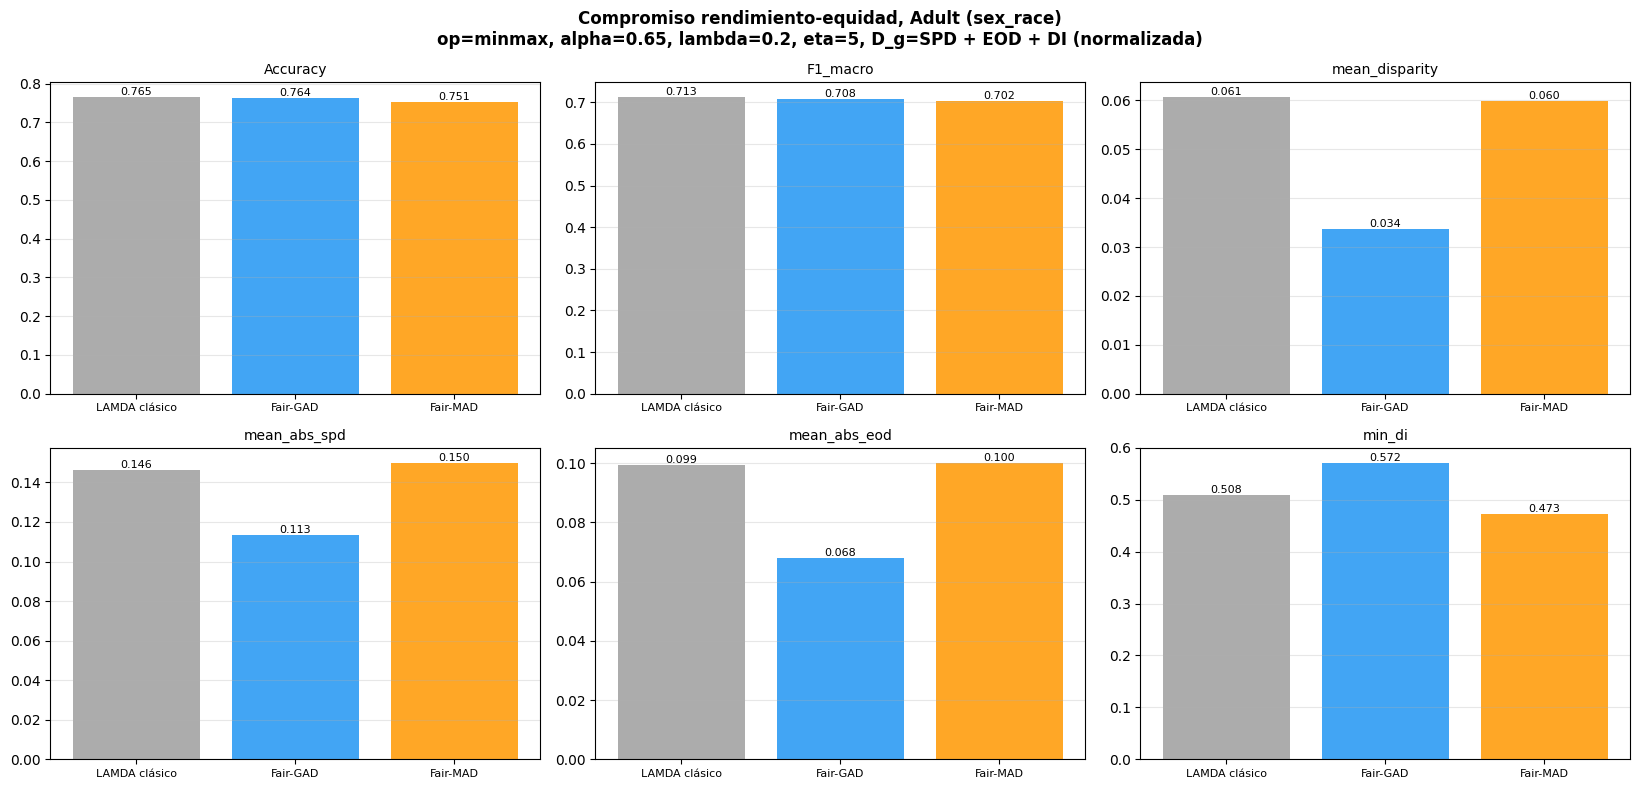

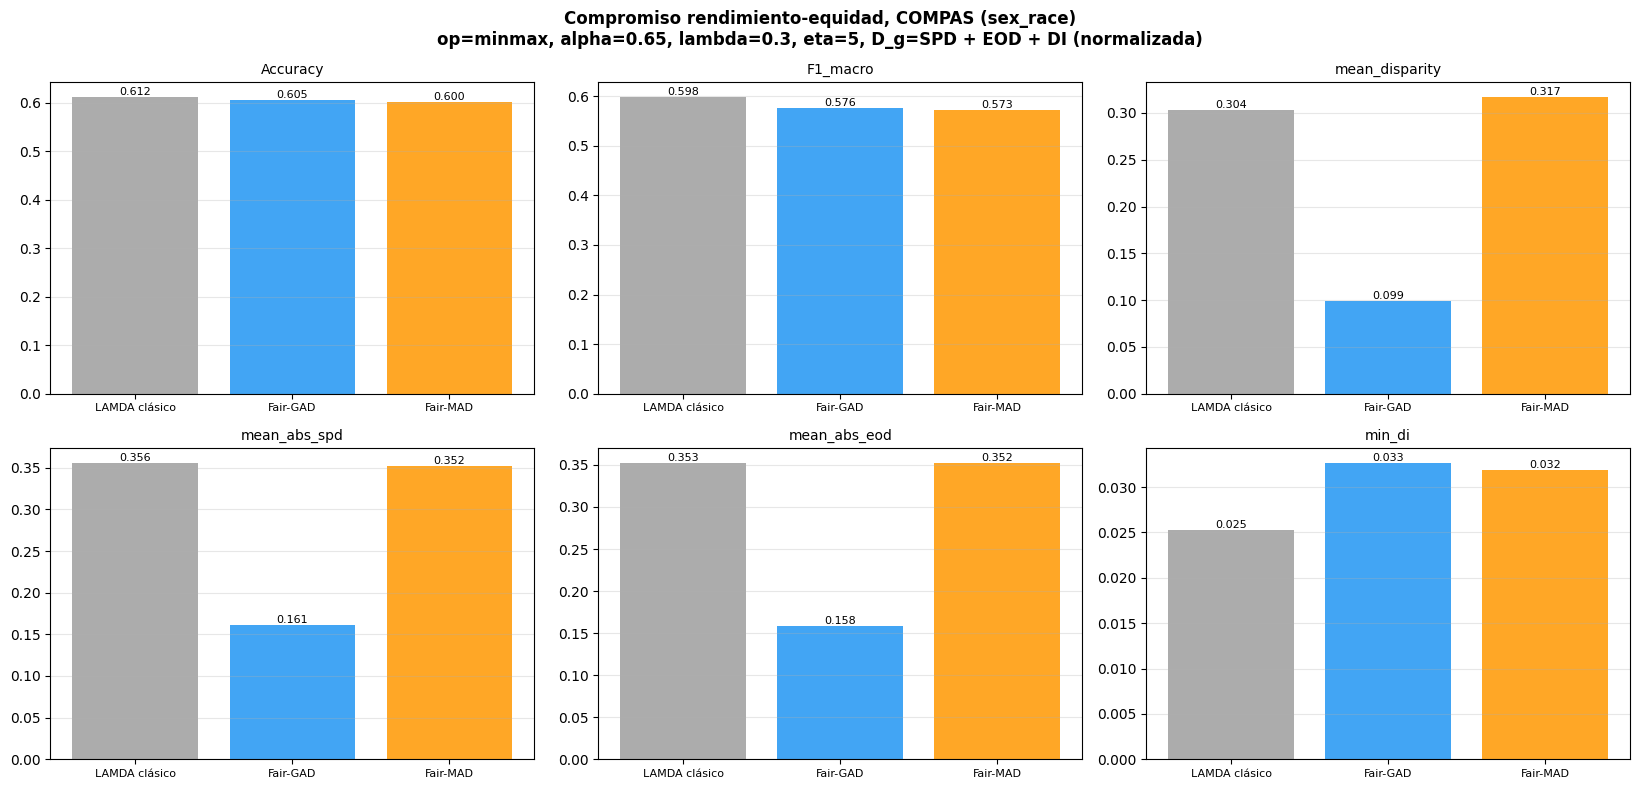

In [10]:
COLORES = ["#9E9E9E", "#2196F3", "#FF9800"]

def figura_compromiso(name, guardar=True):
    """Figura de compromiso rendimiento-equidad de un conjunto."""
    tabla = mitigacion_int[name].mitigation_table
    modelos = tabla.index.tolist()
    metricas = ["Accuracy", "F1_macro", "mean_disparity", "mean_abs_spd",
                "mean_abs_eod", "min_di"]
    metricas = [m for m in metricas if m in tabla.columns]
    ncols = 3
    nrows = int(np.ceil(len(metricas) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4*nrows))
    axes = np.array(axes).flatten()
    x = np.arange(len(modelos))
    for ax, col in zip(axes, metricas):
        bars = ax.bar(x, tabla[col].to_numpy(dtype=float), color=COLORES, alpha=0.85)
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                    ha="center", va="bottom", fontsize=8)
        ax.set_title(col, fontsize=10)
        ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=8)
        ax.grid(axis="y", alpha=0.3)
    for ax in axes[len(metricas):]:
        ax.axis("off")
    plt.suptitle(f"Compromiso rendimiento-equidad, "
                 f"{cfg.DATASETS[name].display_name} ({modo_de(name)})\n"
                 f"op={OPERATOR}, alpha={ALPHA}, lambda={lambda_de(name)}, "
                 f"eta={eta_de(name)}, D_g={descripcion_composicion(name)}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

for name in PANEL_INT:
    figura_compromiso(name)

,Modo,Nº de descriptores,w mínimo,w medio,"Penalizados (w < 0,99)","Penalizados (w < 0,80)"
Dataset,,,,,,
Adult,sex_race,87,0.8459,0.9890,20,0
COMPAS,sex_race,14,0.5638,0.9591,3,1


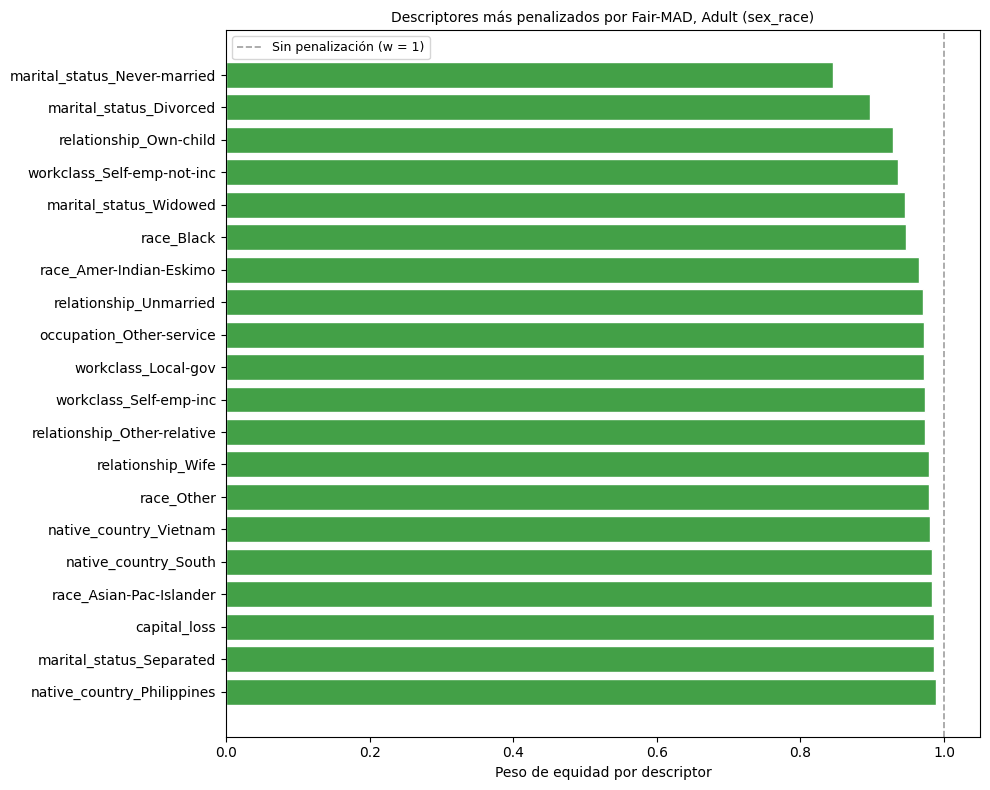

,feature,w_j,D_j
16,marital_status_Never-married,0.8459,0.0364
12,marital_status_Divorced,0.8970,0.0230
36,relationship_Own-child,0.9287,0.0153
9,workclass_Self-emp-not-inc,0.9356,0.0138
18,marital_status_Widowed,0.9454,0.0116
41,race_Black,0.9476,0.0111
39,race_Amer-Indian-Eskimo,0.9648,0.0073
37,relationship_Unmarried,0.9703,0.0061
26,occupation_Other-service,0.9717,0.0058
6,workclass_Local-gov,0.9725,0.0056


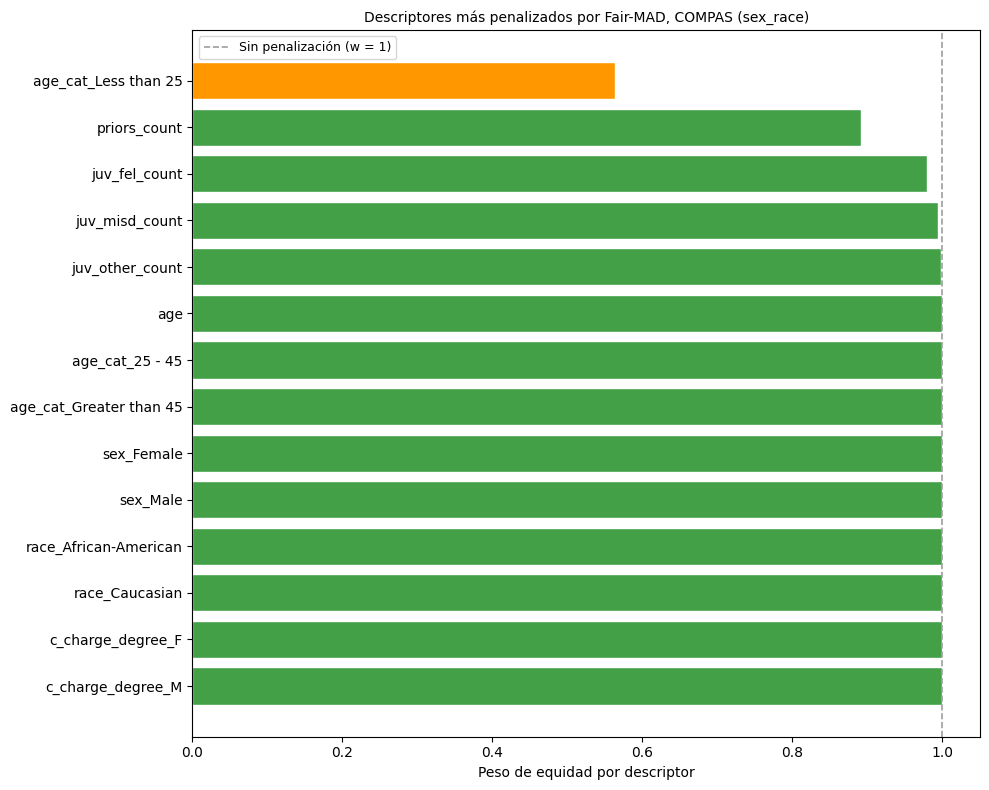

,feature,w_j,D_j
7,age_cat_Less than 25,0.5638,0.1547
4,priors_count,0.8919,0.0242
1,juv_fel_count,0.9789,0.0043
2,juv_misd_count,0.9940,0.0012
3,juv_other_count,0.9984,0.0003
0,age,1.0000,0.0000
5,age_cat_25 - 45,1.0000,0.0000
6,age_cat_Greater than 45,1.0000,0.0000
8,sex_Female,1.0000,0.0000
9,sex_Male,1.0000,0.0000


In [11]:
UMBRAL_SEPARACION = 0.99
TOP_N = 20

filas_desc = []
for name in PANEL_INT:
    w = mitigacion_int[name].descriptor_weights["w_j"].to_numpy(dtype=float)
    filas_desc.append({
        "Dataset": cfg.DATASETS[name].display_name, "Modo": modo_de(name),
        "Nº de descriptores": len(w), "w mínimo": w.min(), "w medio": w.mean(),
        "Penalizados (w < 0,99)": int((w < UMBRAL_SEPARACION).sum()),
        "Penalizados (w < 0,80)": int((w < 0.80).sum()),
    })
resumen_desc_int = pd.DataFrame(filas_desc).set_index("Dataset")
resumen_desc_int.to_csv(os.path.join(RESULTADOS_INT, "descriptores_interseccional.csv"))
display(resumen_desc_int)

def figura_descriptores(name, top_n=TOP_N):
    """Descriptores más penalizados por Fair-MAD en un conjunto."""
    top_df = mitigacion_int[name].descriptor_weights.head(top_n).copy()
    fig, ax = plt.subplots(figsize=(10, max(5, top_n*0.4)))
    colores = ["#E53935" if w < 0.5 else "#FF9800" if w < 0.8 else "#43A047"
               for w in top_df["w_j"]]
    ax.barh(top_df["feature"].astype(str), top_df["w_j"], color=colores, edgecolor="white")
    ax.axvline(x=1.0, color="#9E9E9E", linestyle="--", linewidth=1.2,
               label="Sin penalización (w = 1)")
    ax.set_xlabel("Peso de equidad por descriptor")
    ax.set_xlim(0, 1.05); ax.invert_yaxis(); ax.legend(fontsize=9)
    ax.set_title(f"Descriptores más penalizados por Fair-MAD, "
                 f"{cfg.DATASETS[name].display_name} ({modo_de(name)})", fontsize=10)
    plt.tight_layout()
    plt.show()
    return top_df

tablas_desc_int = {}
for name in PANEL_INT:
    if float(mitigacion_int[name].descriptor_weights["w_j"].min()) < UMBRAL_SEPARACION:
        tablas_desc_int[name] = figura_descriptores(name)
        display(tablas_desc_int[name])
    else:
        print(f"[{name}] sin penalización apreciable: todos los pesos en la unidad.")

## Comparación con el panel principal

Contrasta el resultado con atributo compuesto frente al del atributo marginal, que se lee
de los CSV persistidos por el notebook de mitigación y **no se vuelve a ejecutar**. Las dos
lecturas relevantes son si la disparidad de partida aumenta al mirar los subgrupos, que es
lo que la literatura de sesgo interseccional predice, y si la posición relativa de Fair-MAD
frente a Fair-GAD mejora.

In [12]:
filas_cmp = []
for name, conf in PANEL_INT.items():
    ruta = os.path.join(cfg.RESULTS_DIR, f"{name}_mitigacion.csv")
    if not os.path.exists(ruta):
        print(f"AVISO: no se encuentra {ruta}; ejecuta antes el notebook de mitigación.")
        continue
    marg = pd.read_csv(ruta).set_index("Modelo")
    inter = mitigacion_int[name].mitigation_table

    for etiqueta, tabla, modo in (("marginal", marg, conf["modo_marginal"]),
                                  ("interseccional", inter, conf["modo"])):
        base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
        for modelo in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]:
            d = float(tabla.loc[modelo, "mean_disparity"])
            filas_cmp.append({
                "Dataset": cfg.DATASETS[name].display_name,
                "Atributo": f"{etiqueta} ({modo})",
                "Modelo": modelo,
                "Accuracy": float(tabla.loc[modelo, "Accuracy"]),
                "F1_macro": float(tabla.loc[modelo, "F1_macro"]),
                "D_g": d,
                "Reducción relativa": ((base - d) / base) if base > 0 and modelo != "LAMDA clásico" else np.nan,
                "|SPD|": float(tabla.loc[modelo, "mean_abs_spd"]),
                "|EOD|": float(tabla.loc[modelo, "mean_abs_eod"]),
                "DI mínimo": float(tabla.loc[modelo, "min_di"]),
            })

comparacion = pd.DataFrame(filas_cmp).set_index(["Dataset", "Atributo", "Modelo"])
comparacion.to_csv(os.path.join(RESULTADOS_INT, "comparacion_marginal_interseccional.csv"))
comparacion

Accuracy  F1_macro    D_g  Reducción relativa  |SPD|  |EOD|  DI mínimo
Dataset Atributo                  Modelo                                                                               
Adult   marginal (sex)            LAMDA clásico    0.7654    0.7127 0.0780                 NaN 0.1817 0.0796     0.5238
                                  Fair-GAD         0.7601    0.7034 0.0249              0.6804 0.1132 0.0174     0.6769
                                  Fair-MAD         0.7598    0.7078 0.0641              0.1785 0.1673 0.0599     0.5638
        interseccional (sex_race) LAMDA clásico    0.7654    0.7127 0.0607                 NaN 0.1462 0.0994     0.5084
                                  Fair-GAD         0.7636    0.7077 0.0337              0.4444 0.1134 0.0680     0.5718
                                  Fair-MAD         0.7513    0.7025 0.0599              0.0130 0.1500 0.1002     0.4733
COMPAS  marginal (race)           LAMDA clásico    0.6117    0.5985 0.2633                 NaN 0.3330 0.3171     0.3130
                                  Fair-GAD         0.6117    0.5777 0.0859              0.6737 0.1552 0.1392     0.4982
                                  Fair-MAD         0.6108    0.5971 0.2630              0.0012 0.3321 0.3168     0.3103
        interseccional (sex_race) LAMDA clásico    0.6117    0.5985 0.3036                 NaN 0.3562 0.3528     0.0253
                                  Fair-GAD         0.6051    0.5764 0.0990              0.6739 0.1612 0.1583     0.0327
                                  Fair-MAD         0.6004    0.5729 0.3171             -0.0442 0.3516 0.3520     0.0319

In [13]:
# Diferencia de reducción relativa entre las dos propuestas en cada escenario.
piv = (comparacion.reset_index()
       .query("Modelo != 'LAMDA clásico'")
       .pivot_table(index=["Dataset", "Atributo"], columns="Modelo",
                    values="Reducción relativa"))
piv["Brecha (GAD − MAD)"] = piv["Fair-GAD"] - piv["Fair-MAD"]
display(piv.round(4))


Modelo                             Fair-GAD  Fair-MAD  Brecha (GAD − MAD)
Dataset Atributo                                                         
Adult   interseccional (sex_race)    0.4444    0.0130              0.4314
        marginal (sex)               0.6804    0.1785              0.5020
COMPAS  interseccional (sex_race)    0.6739   -0.0442              0.7181
        marginal (race)              0.6737    0.0012              0.6724

In [14]:
# =========================================================
# DIAGNÓSTICO: sensibilidad a la exclusión del impacto dispar
# =========================================================
# Propósito. En el escenario interseccional el mínimo del impacto dispar se
# calcula sobre ocho pares de grupo y clase en lugar de cuatro, y toma el más
# extremo, que es también el peor estimado: en COMPAS procede de un par con 27
# observaciones. Esta celda comprueba si el deterioro de Fair-MAD depende de ese
# componente o persiste sin él.
#
# Qué se espera. El impacto dispar interviene en la disparidad agregada, que es
# la magnitud de reporte y la señal de control de Fair-MAD, pero NO en la señal
# direccional que gobierna Fair-GAD, compuesta solo por SPD y EOD. Por tanto:
#   - Fair-GAD debe producir exactamente las mismas predicciones y, con ellas,
#     idéntica exactitud, F1 macro, |SPD| y |EOD|. Solo cambia su D_g reportada.
#   - Fair-MAD sí puede cambiar, ya que su señal de control se recompone.
# La celda verifica ese pronóstico de forma explícita.
#
# Esta celda NO persiste con persist_result: sobrescribiría el resultado
# principal de la extensión.

DATASET_DIAG = "compas"

PESOS_SIN_DI = FairnessWeights(spd=1.0, eod=1.0, di=0.0,
                               normalize=NORMALIZAR_DISPARIDAD)

res_sin_di = runner.run_mitigation(
    dataset_name=DATASET_DIAG, sensitive_mode=modo_de(DATASET_DIAG),
    alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
    weights=PESOS_SIN_DI, class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    lambda_fair=lambda_de(DATASET_DIAG), eta_fair=eta_de(DATASET_DIAG),
    tau_j=TAU_J,
    disparity_mode_gad=MODO_DISPARIDAD_GAD,
    disparity_mode_mad=modo_mad_de(DATASET_DIAG),
    **parametros_bloques(DATASET_DIAG),
    default_group_disparity=DEFAULT_GROUP_DISPARITY,
    use_cumulative_history=USE_CUMULATIVE_HISTORY,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)

# ---------------------------------------------------------
# Tabla comparativa de las dos composiciones
# ---------------------------------------------------------
CONFIGS = {
    "con DI (SPD + EOD + DI)": mitigacion_int[DATASET_DIAG].mitigation_table,
    "sin DI (SPD + EOD)":      res_sin_di.mitigation_table,
}

filas = []
for etiqueta, tabla in CONFIGS.items():
    base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
    for modelo in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]:
        d = float(tabla.loc[modelo, "mean_disparity"])
        filas.append({
            "Composición": etiqueta,
            "Modelo": modelo,
            "Accuracy": float(tabla.loc[modelo, "Accuracy"]),
            "F1_macro": float(tabla.loc[modelo, "F1_macro"]),
            "D_g": d,
            "Reducción relativa": ((base - d) / base)
                                  if base > 0 and modelo != "LAMDA clásico" else np.nan,
            "|SPD|": float(tabla.loc[modelo, "mean_abs_spd"]),
            "|EOD|": float(tabla.loc[modelo, "mean_abs_eod"]),
            "DI mínimo": float(tabla.loc[modelo, "min_di"]),
        })

comparacion_di = pd.DataFrame(filas).set_index(["Composición", "Modelo"])
comparacion_di.to_csv(os.path.join(RESULTADOS_INT,
                                   f"{DATASET_DIAG}_sensibilidad_di.csv"))
display(comparacion_di)

# ---------------------------------------------------------
# Verificación del pronóstico sobre Fair-GAD
# ---------------------------------------------------------
COLS_INVARIANTES = ["Accuracy", "F1_macro", "mean_abs_spd", "mean_abs_eod", "min_di"]
con_di = mitigacion_int[DATASET_DIAG].mitigation_table
sin_di = res_sin_di.mitigation_table

iguales = all(np.isclose(float(con_di.loc["Fair-GAD", c]),
                         float(sin_di.loc["Fair-GAD", c]), atol=1e-9)
              for c in COLS_INVARIANTES)

print("\n--- Verificación ---")
print("Fair-GAD invariante a la exclusión del impacto dispar:", iguales)
if not iguales:
    print("AVISO: Fair-GAD cambia al retirar el impacto dispar. No debería, ya que su")
    print("señal direccional se compone solo de SPD y EOD. Revisar la implementación")
    print("antes de interpretar el resto de la tabla.")

# ---------------------------------------------------------
# Lectura del efecto sobre Fair-MAD
# ---------------------------------------------------------
def _reduccion(tabla):
    base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
    fair = float(tabla.loc["Fair-MAD", "mean_disparity"])
    return (base - fair) / base if base > 0 else np.nan

r_con, r_sin = _reduccion(con_di), _reduccion(sin_di)
print(f"\nReducción relativa de Fair-MAD con DI:  {r_con: .4f}")
print(f"Reducción relativa de Fair-MAD sin DI:  {r_sin: .4f}")

if r_con < 0 <= r_sin:
    print("\nEl deterioro de Fair-MAD desaparece al retirar el impacto dispar.")
elif r_sin < 0:
    print("\nEl deterioro persiste sin el impacto dispar.")
else:
    print("\nAmbas composiciones dan reducción no negativa.")

Accuracy  F1_macro    D_g  Reducción relativa  |SPD|  |EOD|  DI mínimo
Composición             Modelo                                                                               
con DI (SPD + EOD + DI) LAMDA clásico    0.6117    0.5985 0.3036                 NaN 0.3562 0.3528     0.0253
                        Fair-GAD         0.6051    0.5764 0.0990              0.6739 0.1612 0.1583     0.0327
                        Fair-MAD         0.6004    0.5729 0.3171             -0.0442 0.3516 0.3520     0.0319
sin DI (SPD + EOD)      LAMDA clásico    0.6117    0.5985 0.2545                 NaN 0.3562 0.3528     0.0253
                        Fair-GAD         0.6051    0.5764 0.0657              0.7420 0.1612 0.1583     0.0327
                        Fair-MAD         0.5606    0.5064 0.1411              0.4457 0.2406 0.2415     0.0445


--- Verificación ---
Fair-GAD invariante a la exclusión del impacto dispar: True

Reducción relativa de Fair-MAD con DI:  -0.0442
Reducción relativa de Fair-MAD sin DI:   0.4457

El deterioro de Fair-MAD desaparece al retirar el impacto dispar.


In [15]:
# =========================================================
# DIAGNÓSTICO 2: ¿ocurre lo mismo en el panel principal?
# =========================================================
# Motivo. En el escenario interseccional, retirar el impacto dispar de la señal
# de control desbloquea a Fair-MAD: pasa de −4,4 % a +44,6 % de reducción. La
# pregunta que eso abre es si el mismo componente está limitando a Fair-MAD en
# el panel principal, donde su reducción en COMPAS es del 0,1 %.
#
# Esta celda ejecuta COMPAS con el atributo sensible MARGINAL del panel (raza) en
# las dos composiciones. La ejecución con impacto dispar debe reproducir
# exactamente la tabla del panel; la celda lo verifica antes de interpretar nada.
#
# No persiste con persist_result: no toca ni el panel ni la extensión.

DATASET_M = "compas"
MODO_M = "race"          # atributo marginal del panel principal

PESOS_CON_DI = FairnessWeights(spd=1.0, eod=1.0, di=1.0,
                               normalize=NORMALIZAR_DISPARIDAD)
PESOS_SIN_DI_M = FairnessWeights(spd=1.0, eod=1.0, di=0.0,
                                 normalize=NORMALIZAR_DISPARIDAD)

def _ejecutar(pesos):
    """Ejecuta la mitigación sobre COMPAS marginal con una composición dada."""
    return runner.run_mitigation(
        dataset_name=DATASET_M, sensitive_mode=MODO_M,
        alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
        weights=pesos, class_aggregation=CLASS_AGGREGATION,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
        lambda_fair=lambda_de(DATASET_M), eta_fair=eta_de(DATASET_M),
        tau_j=TAU_J,
        disparity_mode_gad=MODO_DISPARIDAD_GAD,
        disparity_mode_mad=modo_mad_de(DATASET_M),
        **parametros_bloques(DATASET_M),
        default_group_disparity=DEFAULT_GROUP_DISPARITY,
        use_cumulative_history=USE_CUMULATIVE_HISTORY,
        test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )

res_m_con = _ejecutar(PESOS_CON_DI)
res_m_sin = _ejecutar(PESOS_SIN_DI_M)

# ---------------------------------------------------------
# Control: la ejecución con DI debe reproducir el panel
# ---------------------------------------------------------
# Valores de referencia del panel principal (COMPAS con raza).
REFERENCIA_PANEL = {
    "LAMDA clásico": {"Accuracy": 0.6117, "mean_disparity": 0.2633},
    "Fair-GAD":      {"Accuracy": 0.6117, "mean_disparity": 0.0859},
    "Fair-MAD":      {"Accuracy": 0.6108, "mean_disparity": 0.2630},
}
tabla_con = res_m_con.mitigation_table
coincide = all(
    np.isclose(float(tabla_con.loc[m, k]), v, atol=5e-4)
    for m, cols in REFERENCIA_PANEL.items() for k, v in cols.items()
)
print("La ejecución con impacto dispar reproduce el panel principal:", coincide)
if not coincide:
    print("AVISO: no coincide con la Tabla 5.4. Antes de interpretar nada, revisar")
    print("que los parámetros del esquema por bloques y las intensidades sean los")
    print("del panel; parametros_bloques() se derivó aquí con el modo interseccional.")

# ---------------------------------------------------------
# Tabla comparativa
# ---------------------------------------------------------
filas = []
for etiqueta, tabla in (("marginal, con DI", res_m_con.mitigation_table),
                        ("marginal, sin DI", res_m_sin.mitigation_table)):
    base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
    for modelo in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]:
        d = float(tabla.loc[modelo, "mean_disparity"])
        filas.append({
            "Composición": etiqueta, "Modelo": modelo,
            "Accuracy": float(tabla.loc[modelo, "Accuracy"]),
            "F1_macro": float(tabla.loc[modelo, "F1_macro"]),
            "D_g": d,
            "Reducción relativa": ((base - d) / base)
                                  if base > 0 and modelo != "LAMDA clásico" else np.nan,
            "|SPD|": float(tabla.loc[modelo, "mean_abs_spd"]),
            "|EOD|": float(tabla.loc[modelo, "mean_abs_eod"]),
            "DI mínimo": float(tabla.loc[modelo, "min_di"]),
        })

comparacion_marginal_di = pd.DataFrame(filas).set_index(["Composición", "Modelo"])
comparacion_marginal_di.to_csv(
    os.path.join(RESULTADOS_INT, f"{DATASET_M}_marginal_sensibilidad_di.csv"))
display(comparacion_marginal_di)

# ---------------------------------------------------------
# Lectura
# ---------------------------------------------------------
def _delta(tabla, modelo, col):
    return float(tabla.loc[modelo, col]) - float(tabla.loc["LAMDA clásico", col])

def _reduccion(tabla, modelo):
    base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
    return (base - float(tabla.loc[modelo, "mean_disparity"])) / base if base > 0 else np.nan

r_con = _reduccion(res_m_con.mitigation_table, "Fair-MAD")
r_sin = _reduccion(res_m_sin.mitigation_table, "Fair-MAD")
f1_con = _delta(res_m_con.mitigation_table, "Fair-MAD", "F1_macro")
f1_sin = _delta(res_m_sin.mitigation_table, "Fair-MAD", "F1_macro")

print(f"\nFair-MAD marginal con DI: reducción {r_con: .4f} | Delta F1 macro {f1_con: .4f}")
print(f"Fair-MAD marginal sin DI: reducción {r_sin: .4f} | Delta F1 macro {f1_sin: .4f}")
print("\nLímite de referencia: la mayor caída de F1 macro del panel principal es 0,0208.")

if r_sin > r_con + 0.05:
    print("\nEl impacto dispar también limita a Fair-MAD en el panel principal.")
else:
    print("\nEl impacto dispar no limita a Fair-MAD en el panel principal.")

La ejecución con impacto dispar reproduce el panel principal: True


Accuracy  F1_macro    D_g  Reducción relativa  |SPD|  |EOD|  DI mínimo
Composición      Modelo                                                                               
marginal, con DI LAMDA clásico    0.6117    0.5985 0.2633                 NaN 0.3330 0.3171     0.3130
                 Fair-GAD         0.6117    0.5777 0.0859              0.6737 0.1552 0.1392     0.4982
                 Fair-MAD         0.6108    0.5971 0.2630              0.0012 0.3321 0.3168     0.3103
marginal, sin DI LAMDA clásico    0.6117    0.5985 0.2250                 NaN 0.3330 0.3171     0.3130
                 Fair-GAD         0.6117    0.5777 0.0534              0.7627 0.1552 0.1392     0.4982
                 Fair-MAD         0.6098    0.5897 0.2138              0.0502 0.3201 0.3074     0.2719


Fair-MAD marginal con DI: reducción  0.0012 | Delta F1 macro -0.0014
Fair-MAD marginal sin DI: reducción  0.0502 | Delta F1 macro -0.0088

Límite de referencia: la mayor caída de F1 macro del panel principal es 0,0208.

El impacto dispar no limita a Fair-MAD en el panel principal.


In [16]:
# =========================================================
# BARRIDO DE LAMBDA SOBRE ADULT EN MODO INTERSECCIONAL
# =========================================================
# Hipótesis a contrastar. Al pasar de dos a cuatro grupos, el número de pares de
# grupo y clase se duplica y la violación direccional media por par disminuye, de
# modo que con la misma intensidad la penalización efectiva es más débil. Lo
# respalda que en Adult la reducción caiga de 68,04 % a 44,44 % mientras el coste
# en exactitud también cae, de 0,0053 a 0,0018: el mecanismo penaliza menos, no
# falla. Si la hipótesis es correcta, una intensidad mayor debería recuperar
# reducción a un coste comparable al del panel.
#
# Eficiencia. Solo se entrena Fair-GAD. El clasificador clásico y la partición se
# calculan una sola vez y se reutilizan en todas las intensidades, y Fair-MAD no
# interviene, que es la parte cara del recorrido por bloques.

from lamda.models.lamda_classifier import LamdaClassifier
from lamda.models.lamda_fair_gad_classifier import LamdaFairGADClassifier

DATASET_B = "adult"
REJILLA_LAMBDA = [0.2, 0.3, 0.4, 0.6, 0.8, 1.0]   # 0,2 es la del panel

# --- Partición y modelo clásico, una sola vez -------------------------------
(X_tr, X_te, y_tr, y_te, s_tr, s_te,
 feat_names, ds_conf) = runner.load_and_split(
    DATASET_B, sensitive_mode=modo_de(DATASET_B),
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

clasico = LamdaClassifier(alpha=ALPHA, operator=OPERATOR)
clasico.fit(X_tr, y_tr)
y_pred_clasico = clasico.predict(X_te)

TAREA = ds_conf.task
PESOS_B = pesos_de(DATASET_B)
PB = parametros_bloques(DATASET_B)

fila_base = reporting.summarize_model_metrics(
    y_te, y_pred_clasico, s_te, task=TAREA, thresholds=THRESHOLDS,
    weights=PESOS_B, class_aggregation=CLASS_AGGREGATION)
D_BASE = float(fila_base["mean_disparity"])
print(f"Clásico interseccional | exactitud {fila_base['Accuracy']:.4f} | "
      f"F1 macro {fila_base['F1_macro']:.4f} | D_g {D_BASE:.4f}")

# --- Barrido ----------------------------------------------------------------
filas_b = [{"lambda": np.nan, "Modelo": "LAMDA clásico", **fila_base,
            "Reducción relativa": np.nan}]

for lam in REJILLA_LAMBDA:
    t0 = time.time()
    gad = LamdaFairGADClassifier(
        alpha=ALPHA, operator=OPERATOR, lambda_=lam,
        block_size=PB["block_size"],
        fairness_thresholds=THRESHOLDS, fairness_weights=PESOS_B, clip=True,
        min_group_size=PB["min_group_size"],
        min_positive_size=PB["min_positive_size"],
        default_group_disparity=DEFAULT_GROUP_DISPARITY,
        class_aggregation=CLASS_AGGREGATION,
        use_cumulative_history=USE_CUMULATIVE_HISTORY,
        disparity_mode=MODO_DISPARIDAD_GAD,
    )
    gad.fit(X_tr, y_tr)
    gad.predict_blocks(X=X_tr, y_true=y_tr, sensitive=s_tr, return_details=False)
    y_pred_gad = gad.predict_fair_from_disparities(X=X_te, sensitive=s_te)

    met = reporting.summarize_model_metrics(
        y_te, y_pred_gad, s_te, task=TAREA, thresholds=THRESHOLDS,
        weights=PESOS_B, class_aggregation=CLASS_AGGREGATION)
    red = (D_BASE - float(met["mean_disparity"])) / D_BASE if D_BASE > 0 else np.nan
    filas_b.append({"lambda": lam, "Modelo": "Fair-GAD", **met,
                    "Reducción relativa": red})
    print(f"  lambda={lam:<4} | {time.time()-t0:5.1f}s | "
          f"exactitud {met['Accuracy']:.4f} | F1 macro {met['F1_macro']:.4f} | "
          f"D_g {met['mean_disparity']:.4f} | reducción {red:.4f}")

COLS_B = ["lambda", "Modelo", "Accuracy", "F1_macro", "mean_disparity",
          "Reducción relativa", "mean_abs_spd", "mean_abs_eod", "min_di"]
barrido_lambda = pd.DataFrame(filas_b)[COLS_B].set_index(["Modelo", "lambda"])
barrido_lambda.to_csv(os.path.join(RESULTADOS_INT,
                                   f"{DATASET_B}_barrido_lambda_interseccional.csv"))
display(barrido_lambda.round(4))

# --- Lectura ----------------------------------------------------------------
# Referencias del panel principal, Adult con el atributo marginal.
RED_PANEL, DACC_PANEL, DF1_PANEL = 0.6804, -0.0053, -0.0093

resumen_b = barrido_lambda.reset_index().query("Modelo == 'Fair-GAD'").copy()
resumen_b["Delta Accuracy"] = resumen_b["Accuracy"] - float(fila_base["Accuracy"])
resumen_b["Delta F1 macro"] = resumen_b["F1_macro"] - float(fila_base["F1_macro"])

print(f"\nReferencia del panel (Adult marginal): reducción {RED_PANEL:.4f}, "
      f"Delta exactitud {DACC_PANEL:.4f}, Delta F1 macro {DF1_PANEL:.4f}")

# Intensidades que igualan o superan la reducción del panel sin exceder su coste.
aptas = resumen_b[(resumen_b["Reducción relativa"] >= RED_PANEL * 0.9) &
                  (resumen_b["Delta F1 macro"] >= DF1_PANEL * 2)]
display(resumen_b[["lambda", "Reducción relativa", "Delta Accuracy",
                   "Delta F1 macro"]].round(4))

if len(aptas):
    lam_ok = float(aptas["lambda"].min())
    print(f"\nCon lambda = {lam_ok} se recupera al menos el 90 % de la reducción "
          f"del panel sin duplicar su coste en F1 macro.")
else:
    print("\nNinguna intensidad de la rejilla recupera la reducción del panel "
          "dentro de un coste comparable.")

Clásico interseccional | exactitud 0.7654 | F1 macro 0.7127 | D_g 0.0607
  lambda=0.2  |   0.8s | exactitud 0.7636 | F1 macro 0.7077 | D_g 0.0337 | reducción 0.4444
  lambda=0.3  |   0.8s | exactitud 0.7646 | F1 macro 0.7047 | D_g 0.0296 | reducción 0.5129
  lambda=0.4  |   0.8s | exactitud 0.7646 | F1 macro 0.7047 | D_g 0.0296 | reducción 0.5129
  lambda=0.6  |   0.8s | exactitud 0.7666 | F1 macro 0.7064 | D_g 0.0317 | reducción 0.4777
  lambda=0.8  |   0.8s | exactitud 0.7663 | F1 macro 0.7060 | D_g 0.0314 | reducción 0.4831
  lambda=1.0  |   0.8s | exactitud 0.7697 | F1 macro 0.7091 | D_g 0.0357 | reducción 0.4113


Accuracy  F1_macro  mean_disparity  Reducción relativa  mean_abs_spd  mean_abs_eod  min_di
Modelo        lambda                                                                                            
LAMDA clásico NaN       0.7654    0.7127          0.0607                 NaN        0.1462        0.0994  0.5084
Fair-GAD      0.2000    0.7636    0.7077          0.0337              0.4444        0.1134        0.0680  0.5718
              0.3000    0.7646    0.7047          0.0296              0.5129        0.1037        0.0581  0.5471
              0.4000    0.7646    0.7047          0.0296              0.5129        0.1037        0.0581  0.5471
              0.6000    0.7666    0.7064          0.0317              0.4777        0.1061        0.0595  0.5516
              0.8000    0.7663    0.7060          0.0314              0.4831        0.1057        0.0591  0.5516
              1.0000    0.7697    0.7091          0.0357              0.4113        0.1097        0.0621  0.5590


Referencia del panel (Adult marginal): reducción 0.6804, Delta exactitud -0.0053, Delta F1 macro -0.0093


,lambda,Reducción relativa,Delta Accuracy,Delta F1 macro
1,0.2000,0.4444,-0.0018,-0.0051
2,0.3000,0.5129,-0.0008,-0.0080
3,0.4000,0.5129,-0.0008,-0.0080
4,0.6000,0.4777,0.0012,-0.0063
5,0.8000,0.4831,0.0008,-0.0067
6,1.0000,0.4113,0.0043,-0.0036



Ninguna intensidad de la rejilla recupera la reducción del panel dentro de un coste comparable.


In [17]:
# =========================================================
# 6. AMPLIACIÓN DEL PANEL: DUTCH CENSUS
# =========================================================
# El cargador de Dutch Census se ha ampliado con dos modos compuestos,
# 'sex_age' y 'sex_marital', además de los marginales 'age' y 'marital'. La
# modificación es estrictamente aditiva: el modo 'sex' que emplea el panel
# principal produce exactamente el mismo atributo sensible que antes, de modo
# que ningún resultado del panel principal se ve afectado. El tramo de edad
# se dicotomiza en age <= 8. El corte se fija de antemano por equilibrio
# muestral (52,8 % frente a 47,2 % de la muestra) y no atendiendo a la
# disparidad observada, para no incurrir en selección del atributo en función
# del resultado que se quiere medir.

import importlib
from typing import get_args
from lamda.data import load_dutch as _ld

importlib.reload(_ld)
object.__setattr__(cfg.DATASETS["dutch"], "loader", _ld.load_dutch_dataset)
print("Modos disponibles en el cargador de Dutch:", get_args(_ld.SENSITIVE_MODE))

# ---------------------------------------------------------
# Diagnóstico de soportes de los dos modos compuestos
# ---------------------------------------------------------
# Criterio de admisión, declarado a priori y coincidente con el aplicado a
# Adult y COMPAS: un modo es admisible si el grupo menor y el par de grupo y
# clase menor del conjunto de entrenamiento superan los soportes mínimos que
# el propio esquema por bloques exige. Entre los modos admisibles se emplea
# 'sex_age', que produce cuatro grupos y reproduce por tanto la estructura de
# los otros dos conjuntos de la extensión. 'sex_marital' se reporta solo como
# diagnóstico de soporte.

filas_dutch = []
_cache_dutch = {}
for modo in ("sex_age", "sex_marital"):
    Xtr, Xte, ytr, yte, str_, ste, *_ = runner.load_and_split(
        "dutch", sensitive_mode=modo, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

    n_train = len(Xtr)
    n_clases = int(len(np.unique(ytr)))
    bs = cfg.tamano_bloque(n_train, BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
    mg, mp = cfg.soportes_minimos(n_train, n_classes=n_clases,
                                  block_size=bs, modo=MODO_SOPORTES)

    s_tr, y_tr = np.asarray(str_), np.asarray(ytr)
    s_te, y_te = np.asarray(ste), np.asarray(yte)
    grupos = sorted(set(s_tr))
    menor_grupo = min((s_tr == g).sum() for g in grupos)
    menor_par = min(((s_tr == g) & (y_tr == c)).sum()
                    for g in grupos for c in np.unique(y_tr))
    menor_par_test = min(((s_te == g) & (y_te == c)).sum()
                         for g in grupos for c in np.unique(y_te))

    _cache_dutch[modo] = dict(n_train=n_train, n_clases=n_clases, bs=bs, mg=mg, mp=mp,
                              n_bloques=int(np.ceil(n_train / bs)))
    filas_dutch.append({
        "Modo": modo, "Grupos": len(grupos), "n_train": n_train,
        "Soporte grupo exigido": mg, "Grupo menor en train": int(menor_grupo),
        "Soporte grupo-clase exigido": mp, "Par menor en train": int(menor_par),
        "Par menor en test": int(menor_par_test),
        "Admisible": bool(menor_grupo >= mg and menor_par >= mp),
    })

soportes_dutch = pd.DataFrame(filas_dutch).set_index("Modo")
display(soportes_dutch)

admisibles = soportes_dutch.index[soportes_dutch["Admisible"]].tolist()
if "sex_age" in admisibles:
    MODO_DUTCH = "sex_age"
elif admisibles:
    MODO_DUTCH = admisibles[0]
else:
    MODO_DUTCH = None

print("\nModos admisibles:", admisibles)
print("Modo seleccionado para la extensión:", MODO_DUTCH)
if MODO_DUTCH is None:
    print("AVISO: ningún modo compuesto de Dutch supera los soportes mínimos. "
          "El conjunto debe quedar excluido de la extensión, igual que "
          "Communities and Crime y Student.")

Modos disponibles en el cargador de Dutch: ('sex', 'age', 'marital', 'sex_age', 'sex_marital')


,Grupos,n_train,Soporte grupo exigido,Grupo menor en train,Soporte grupo-clase exigido,Par menor en train,Par menor en test,Admisible
Modo,,,,,,,,
sex_age,4,48336,50,10208,25,3536,818,True
sex_marital,8,48336,50,138,25,57,11,True



Modos admisibles: ['sex_age', 'sex_marital']
Modo seleccionado para la extensión: sex_age


In [18]:
# =========================================================
# 7. REGISTRO DE DUTCH EN EL PANEL Y DETECCIÓN
# =========================================================
# Se incorpora Dutch Census a las estructuras de configuración de la extensión
# con exactamente los mismos valores que emplea en el panel principal:
# composición SPD + EOD + DI normalizada, lambda 0,2, eta 10 y señal simétrica
# para Fair-MAD. No se recalibra ninguna intensidad, por la misma razón que en
# Adult y COMPAS: se quiere aislar el efecto del cambio de atributo sensible.

assert MODO_DUTCH is not None, "Dutch no ha superado el criterio de soporte."

PANEL_INT["dutch"] = {"modo": MODO_DUTCH, "modo_marginal": "sex"}
COMPOSICION_POR_DATASET["dutch"] = {"spd": 1.0, "eod": 1.0, "di": 1.0}
LAMBDA_POR_DATASET["dutch"] = 0.2
ETA_POR_DATASET["dutch"] = 10
MODO_MAD_POR_DATASET["dutch"] = "symmetric"

_c = _cache_dutch[MODO_DUTCH]
CONFIG_BLOQUES["dutch"] = {"block_size": _c["bs"], "min_group": _c["mg"],
                           "min_pos": _c["mp"], "U": UPDATE_EVERY_N_BLOCKS,
                           "n_train": _c["n_train"], "n_clases": _c["n_clases"],
                           "n_bloques": _c["n_bloques"]}

# Fila de configuración, con las mismas columnas que las de Adult y COMPAS.
_sop = soportes_dutch.loc[MODO_DUTCH]
fila_cfg = {
    "Dataset": cfg.DATASETS["dutch"].display_name,
    "Modo": MODO_DUTCH, "Grupos": int(_sop["Grupos"]),
    "n_train": _c["n_train"], "Tamaño de bloque": _c["bs"],
    "Nº de bloques": _c["n_bloques"],
    "Soporte grupo exigido": _c["mg"],
    "Grupo menor en train": int(_sop["Grupo menor en train"]),
    "Soporte grupo-clase exigido": _c["mp"],
    "Par menor en train": int(_sop["Par menor en train"]),
    "lambda": lambda_de("dutch"), "eta": eta_de("dutch"),
    "Composición": descripcion_composicion("dutch"),
}
config_int = pd.concat(
    [config_int, pd.DataFrame([fila_cfg]).set_index("Dataset")])
config_int.to_csv(os.path.join(RESULTADOS_INT, "configuracion_interseccional.csv"))
display(config_int)

# ---------------------------------------------------------
# Detección con el atributo compuesto
# ---------------------------------------------------------
res = runner.run_detection(
    dataset_name="dutch", sensitive_mode=modo_de("dutch"),
    alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
    weights=pesos_de("dutch"), class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
deteccion_int["dutch"] = res
print(f"[dutch] detección completada | modo={modo_de('dutch')}")
display(res.detection_table)

# Detalle por grupo y clase, con los soportes de test de cada fila.
y_true = res.predictions["y_test"]
y_pred = res.predictions["classic"]
s = res.predictions["sensitive_test"]

det = reporting.flatten_group_class_report(
    reporting.compute_group_class_fairness(
        y_true, y_pred, s, thresholds=THRESHOLDS, weights=pesos_de("dutch")))
det = det.merge(reporting.compute_normal_di_df(y_true, y_pred, s),
                on=["group", "target_class"], how="left")

s_arr, y_arr = np.asarray(s), np.asarray(y_true)
det["n_grupo"] = [int((s_arr == g).sum()) for g in det["group"]]
det["n_grupo_clase"] = [int(((s_arr == g) & (y_arr == c)).sum())
                        for g, c in zip(det["group"], det["target_class"])]
det = det[["group", "target_class", "n_grupo", "n_grupo_clase",
           "spd", "eod", "di", "disparity"]].round(4)
det.to_csv(os.path.join(RESULTADOS_INT, "dutch_detalle_grupo_clase.csv"), index=False)
detalles_int["dutch"] = det

print(f"\n=== {cfg.DATASETS['dutch'].display_name} | modo {modo_de('dutch')} ===")
display(det)

por_grupo = det.groupby("group")["disparity"].mean().round(6)
display(por_grupo.rename("Disparidad agregada del grupo"))
difiere = por_grupo.nunique() > 1
print("¿La disparidad agregada difiere entre grupos?:", difiere)
if not difiere:
    print("AVISO: sigue siendo invariante. Con cuatro grupos no debería serlo; "
          "revisar que el modo interseccional se haya aplicado realmente.")

# Comparación de la disparidad de partida frente al atributo marginal.
_ruta_marg = os.path.join(cfg.RESULTS_DIR, "dutch_mitigacion.csv")
_ETIQ = "LAMDA clásico"
if os.path.exists(_ruta_marg) and _ETIQ in res.detection_table.index:
    _marg = pd.read_csv(_ruta_marg).set_index("Modelo")
    print("\nDisparidad agregada del modelo clásico:")
    print(f"  marginal (sex)           : "
          f"{float(_marg.loc[_ETIQ, 'mean_disparity']):.4f}")
    print(f"  compuesto ({MODO_DUTCH})  : "
          f"{float(res.detection_table.loc[_ETIQ, 'mean_disparity']):.4f}")

,Modo,Grupos,n_train,Tamaño de bloque,Nº de bloques,Soporte grupo exigido,Grupo menor en train,Soporte grupo-clase exigido,Par menor en train,lambda,eta,Composición
Dataset,,,,,,,,,,,,
Adult,sex_race,4,24111,1206,20,50,1486,25,112,0.2000,5,SPD + EOD + DI (normalizada)
COMPAS,sex_race,4,4222,212,20,50,379,25,143,0.3000,5,SPD + EOD + DI (normalizada)
Dutch Census,sex_age,4,48336,2417,20,50,10208,25,3536,0.2000,10,SPD + EOD + DI (normalizada)


[dutch] detección completada | modo=sex_age


,n,Accuracy,F1_macro,F1_weighted,F1_binary,mean_disparity,max_disparity,mean_abs_spd,max_abs_spd,mean_abs_eod,max_abs_eod,mean_di,min_di
Modelo,,,,,,,,,,,,,
LAMDA clásico,12084,0.7282,0.7282,0.7280,0.7320,0.0329,0.1030,0.1128,0.2248,0.0373,0.1171,1.0205,0.5673



=== Dutch Census | modo sex_age ===


,group,target_class,n_grupo,n_grupo_clase,spd,eod,di,disparity
0,female_age<=8,0,3504,2527,0.1401,0.0152,1.3327,0.0299
1,female_age<=8,1,3504,977,-0.1401,-0.0084,0.7579,0.0274
2,female_age>8,0,2572,1579,0.0850,0.0313,1.1916,0.0000
3,female_age>8,1,2572,993,-0.0850,-0.0345,0.8472,0.0000
4,male_age<=8,0,2910,1407,-0.0014,0.0213,0.9971,0.0000
5,male_age<=8,1,2910,1503,0.0014,-0.0252,1.0025,0.0000
6,male_age>8,0,3098,818,-0.2248,-0.1171,0.5673,0.1248
7,male_age>8,1,3098,2280,0.2248,0.0459,1.4678,0.0812


group
female_age<=8   0.0286
female_age>8    0.0000
male_age<=8     0.0000
male_age>8      0.1030
Name: Disparidad agregada del grupo, dtype: float64

¿La disparidad agregada difiere entre grupos?: True

Disparidad agregada del modelo clásico:
  marginal (sex)           : 0.0559
  compuesto (sex_age)  : 0.0329


[dutch] 39.5s | modo=sex_age -> persistido


n  Accuracy  F1_macro  F1_weighted  F1_binary  mean_disparity  mean_abs_spd  max_abs_spd  mean_abs_eod  max_abs_eod  mean_di  min_di
Dataset      Modelo                                                                                                                                                 
Adult        LAMDA clásico   6028    0.7654    0.7127       0.7745     0.5897          0.0607        0.1462       0.1889        0.0994       0.2210   1.0138  0.5084
             Fair-GAD        6028    0.7636    0.7077       0.7719     0.5798          0.0337        0.1134       0.1412        0.0680       0.1974   0.9931  0.5718
             Fair-MAD        6028    0.7513    0.7025       0.7630     0.5819          0.0599        0.1500       0.1887        0.1002       0.2404   1.0038  0.4733
COMPAS       LAMDA clásico   1056    0.6117    0.5985       0.6028     0.6715          0.3036        0.3562       0.4546        0.3528       0.4935   1.2808  0.0253
             Fair-GAD        1056    0.6051    0.5764       0.5829     0.6867          0.0990        0.1612       0.2872        0.1583       0.3872   1.0147  0.0327
             Fair-MAD        1056    0.6004    0.5729       0.5792     0.6813          0.3171        0.3516       0.4898        0.3520       0.5916   2.4917  0.0319
Dutch Census LAMDA clásico  12084    0.7282    0.7282       0.7280     0.7320          0.0329        0.1128       0.2248        0.0373       0.1171   1.0205  0.5673
             Fair-GAD       12084    0.7207    0.7207       0.7207     0.7208          0.0169        0.0946       0.1709        0.0193       0.0706   1.0128  0.6711
             Fair-MAD       12084    0.7308    0.7308       0.7307     0.7328          0.0273        0.1119       0.2149        0.0321       0.0881   1.0188  0.5897

Accuracy  Delta Accuracy  F1_macro  Delta F1_macro    D_g  Delta D_g  Reducción relativa  Delta |SPD|  Delta |EOD|  Delta DI mínimo                         Lectura
Dataset      Modelo                                                                                                                                                                       
Adult        Fair-GAD    0.7636         -0.0018    0.7077         -0.0051 0.0337    -0.0270              0.4444      -0.0328      -0.0314           0.0634  reduce la disparidad observada
             Fair-MAD    0.7513         -0.0141    0.7025         -0.0103 0.0599    -0.0008              0.0130       0.0038       0.0008          -0.0351  reduce la disparidad observada
COMPAS       Fair-GAD    0.6051         -0.0066    0.5764         -0.0221 0.0990    -0.2046              0.6739      -0.1949      -0.1946           0.0074  reduce la disparidad observada
             Fair-MAD    0.6004         -0.0114    0.5729         -0.0256 0.3171     0.0134             -0.0442      -0.0046      -0.0008           0.0066           empeora la disparidad
Dutch Census Fair-GAD    0.7207         -0.0075    0.7207         -0.0075 0.0169    -0.0160              0.4873      -0.0182      -0.0180           0.1038  reduce la disparidad observada
             Fair-MAD    0.7308          0.0026    0.7308          0.0026 0.0273    -0.0056              0.1708      -0.0010      -0.0053           0.0224  reduce la disparidad observada

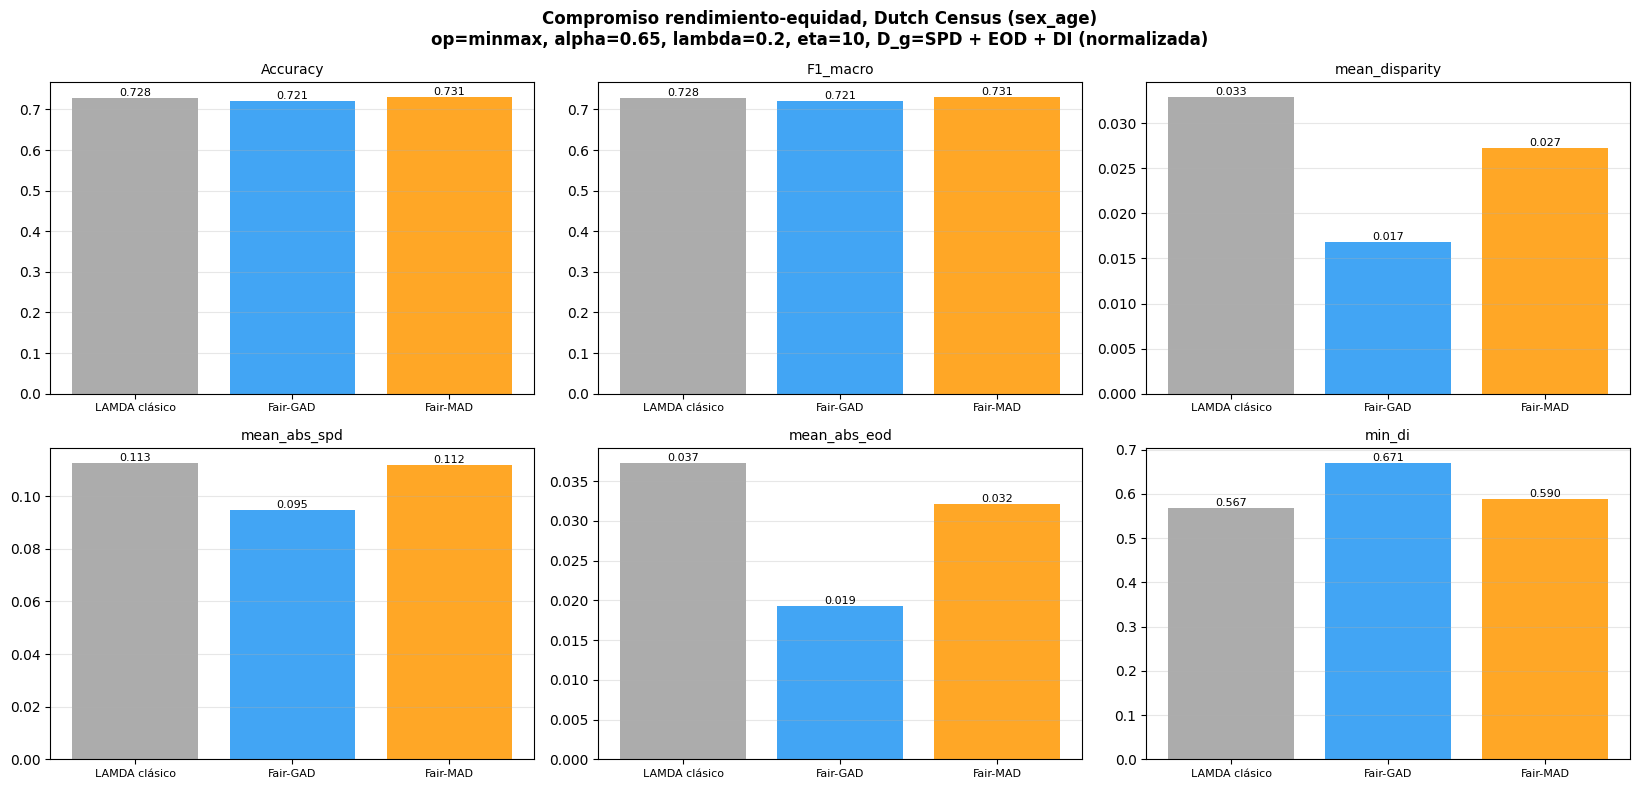

,Modo,Nº de descriptores,w mínimo,w medio,"Penalizados (w < 0,99)","Penalizados (w < 0,80)"
Dataset,,,,,,
Adult,sex_race,87,0.8459,0.9890,20,0
COMPAS,sex_race,14,0.5638,0.9591,3,1
Dutch Census,sex_age,50,0.8286,0.9747,16,0


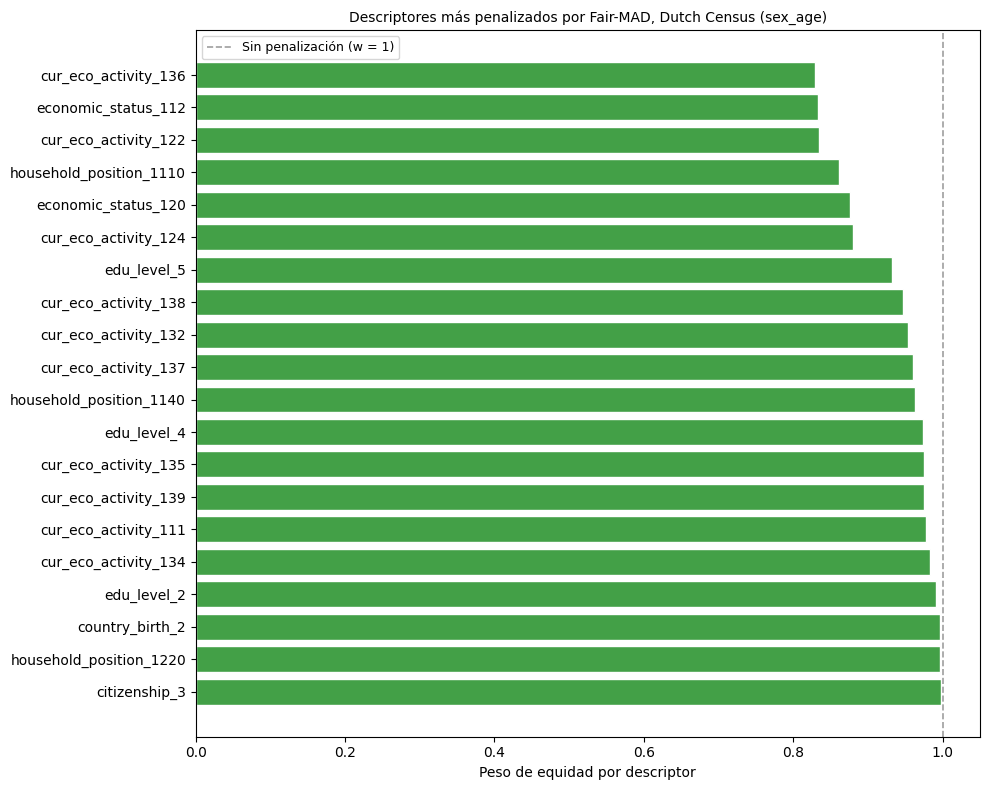

,feature,w_j,D_j
42,cur_eco_activity_136,0.8286,0.0207
32,economic_status_112,0.8332,0.0200
35,cur_eco_activity_122,0.8338,0.0199
3,household_position_1110,0.8617,0.0160
33,economic_status_120,0.8758,0.0142
36,cur_eco_activity_124,0.8796,0.0137
30,edu_level_5,0.9316,0.0073
44,cur_eco_activity_138,0.9474,0.0056
38,cur_eco_activity_132,0.9541,0.0048
43,cur_eco_activity_137,0.9608,0.0041


Accuracy  F1_macro    D_g  Reducción relativa  |SPD|  |EOD|  DI mínimo
Dataset      Atributo                  Modelo                                                                               
Adult        marginal (sex)            LAMDA clásico    0.7654    0.7127 0.0780                 NaN 0.1817 0.0796     0.5238
                                       Fair-GAD         0.7601    0.7034 0.0249              0.6804 0.1132 0.0174     0.6769
                                       Fair-MAD         0.7598    0.7078 0.0641              0.1785 0.1673 0.0599     0.5638
             interseccional (sex_race) LAMDA clásico    0.7654    0.7127 0.0607                 NaN 0.1462 0.0994     0.5084
                                       Fair-GAD         0.7636    0.7077 0.0337              0.4444 0.1134 0.0680     0.5718
                                       Fair-MAD         0.7513    0.7025 0.0599              0.0130 0.1500 0.1002     0.4733
COMPAS       marginal (race)           LAMDA clásico    0.6117    0.5985 0.2633                 NaN 0.3330 0.3171     0.3130
                                       Fair-GAD         0.6117    0.5777 0.0859              0.6737 0.1552 0.1392     0.4982
                                       Fair-MAD         0.6108    0.5971 0.2630              0.0012 0.3321 0.3168     0.3103
             interseccional (sex_race) LAMDA clásico    0.6117    0.5985 0.3036                 NaN 0.3562 0.3528     0.0253
                                       Fair-GAD         0.6051    0.5764 0.0990              0.6739 0.1612 0.1583     0.0327
                                       Fair-MAD         0.6004    0.5729 0.3171             -0.0442 0.3516 0.3520     0.0319
Dutch Census marginal (sex)            LAMDA clásico    0.7282    0.7282 0.0559                 NaN 0.1724 0.0344     0.6852
                                       Fair-GAD         0.7201    0.7197 0.0169              0.6976 0.1253 0.0129     0.7499
                                       Fair-MAD         0.7188    0.7185 0.0399              0.2867 0.1524 0.0179     0.7058
             interseccional (sex_age)  LAMDA clásico    0.7282    0.7282 0.0329                 NaN 0.1128 0.0373     0.5673
                                       Fair-GAD         0.7207    0.7207 0.0169              0.4873 0.0946 0.0193     0.6711
                                       Fair-MAD         0.7308    0.7308 0.0273              0.1708 0.1119 0.0321     0.5897

Modelo                                  Fair-GAD  Fair-MAD  Brecha (GAD − MAD)
Dataset      Atributo                                                         
Adult        interseccional (sex_race)    0.4444    0.0130              0.4314
             marginal (sex)               0.6804    0.1785              0.5020
COMPAS       interseccional (sex_race)    0.6739   -0.0442              0.7181
             marginal (race)              0.6737    0.0012              0.6724
Dutch Census interseccional (sex_age)     0.4873    0.1708              0.3165
             marginal (sex)               0.6976    0.2867              0.4109

In [19]:
# =========================================================
# 8. MITIGACIÓN CON ATRIBUTO COMPUESTO EN DUTCH Y TABLAS FINALES
# =========================================================
# Ejecuta los tres modelos sobre Dutch con el atributo compuesto y reconstruye
# después las tablas agregadas de la extensión con los tres conjuntos. La
# persistencia se realiza de nuevo en el subdirectorio propio, nunca en
# resultados/, que contiene el panel principal.

t0 = time.time()
res_mit = runner.run_mitigation(
    dataset_name="dutch", sensitive_mode=modo_de("dutch"),
    alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
    weights=pesos_de("dutch"), class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    lambda_fair=lambda_de("dutch"), eta_fair=eta_de("dutch"), tau_j=TAU_J,
    disparity_mode_gad=MODO_DISPARIDAD_GAD,
    disparity_mode_mad=modo_mad_de("dutch"),
    **parametros_bloques("dutch"),
    default_group_disparity=DEFAULT_GROUP_DISPARITY,
    use_cumulative_history=USE_CUMULATIVE_HISTORY,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
mitigacion_int["dutch"] = res_mit
runner.persist_result(res_mit, results_dir=RESULTADOS_INT)
print(f"[dutch] {time.time()-t0:.1f}s | modo={modo_de('dutch')} -> persistido")

# ---------------------------------------------------------
# Tabla de los tres modelos, con los tres conjuntos
# ---------------------------------------------------------
filas = []
for name in PANEL_INT:
    mt = mitigacion_int[name].mitigation_table
    for modelo in mt.index:
        fila = {"Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo}
        for col in COLS:
            fila[col] = mt.loc[modelo, col] if col in mt.columns else np.nan
        filas.append(fila)

tabla_modelos_int = pd.DataFrame(filas).set_index(["Dataset", "Modelo"])
tabla_modelos_int.to_csv(os.path.join(RESULTADOS_INT, "modelos_interseccional.csv"))
display(tabla_modelos_int)

# ---------------------------------------------------------
# Resumen con la lectura del efecto
# ---------------------------------------------------------
res_rows = []
for name, r in mitigacion_int.items():
    mt = r.mitigation_table
    base = mt.loc["LAMDA clásico"]
    for modelo in ["Fair-GAD", "Fair-MAD"]:
        fila = mt.loc[modelo]
        d_disp = fila["mean_disparity"] - base["mean_disparity"]
        base_disp = base["mean_disparity"]
        res_rows.append({
            "Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo,
            "Accuracy": fila["Accuracy"],
            "Delta Accuracy": fila["Accuracy"] - base["Accuracy"],
            "F1_macro": fila["F1_macro"],
            "Delta F1_macro": fila["F1_macro"] - base["F1_macro"],
            "D_g": fila["mean_disparity"], "Delta D_g": d_disp,
            "Reducción relativa": (-d_disp / base_disp) if base_disp > 0 else np.nan,
            "Delta |SPD|": fila["mean_abs_spd"] - base["mean_abs_spd"],
            "Delta |EOD|": fila["mean_abs_eod"] - base["mean_abs_eod"],
            "Delta DI mínimo": fila["min_di"] - base["min_di"],
            "Lectura": _lectura(d_disp, base_disp),
        })

resumen_int = pd.DataFrame(res_rows).set_index(["Dataset", "Modelo"])
resumen_int.to_csv(os.path.join(RESULTADOS_INT, "resumen_interseccional.csv"))
display(resumen_int)

# ---------------------------------------------------------
# Figuras de Dutch
# ---------------------------------------------------------
figura_compromiso("dutch")

filas_desc = []
for name in PANEL_INT:
    w = mitigacion_int[name].descriptor_weights["w_j"].to_numpy(dtype=float)
    filas_desc.append({
        "Dataset": cfg.DATASETS[name].display_name, "Modo": modo_de(name),
        "Nº de descriptores": len(w), "w mínimo": w.min(), "w medio": w.mean(),
        "Penalizados (w < 0,99)": int((w < UMBRAL_SEPARACION).sum()),
        "Penalizados (w < 0,80)": int((w < 0.80).sum()),
    })
resumen_desc_int = pd.DataFrame(filas_desc).set_index("Dataset")
resumen_desc_int.to_csv(os.path.join(RESULTADOS_INT, "descriptores_interseccional.csv"))
display(resumen_desc_int)

if float(mitigacion_int["dutch"].descriptor_weights["w_j"].min()) < UMBRAL_SEPARACION:
    tablas_desc_int["dutch"] = figura_descriptores("dutch")
    display(tablas_desc_int["dutch"])
else:
    print("[dutch] sin penalización apreciable: todos los pesos en la unidad.")

# ---------------------------------------------------------
# Comparación marginal frente a compuesto, con los tres conjuntos
# ---------------------------------------------------------
filas_cmp = []
for name, conf in PANEL_INT.items():
    ruta = os.path.join(cfg.RESULTS_DIR, f"{name}_mitigacion.csv")
    if not os.path.exists(ruta):
        print(f"AVISO: no se encuentra {ruta}; ejecuta antes el notebook de mitigación.")
        continue
    marg = pd.read_csv(ruta).set_index("Modelo")
    inter = mitigacion_int[name].mitigation_table

    for etiqueta, tabla, modo in (("marginal", marg, conf["modo_marginal"]),
                                  ("interseccional", inter, conf["modo"])):
        base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
        for modelo in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]:
            d = float(tabla.loc[modelo, "mean_disparity"])
            filas_cmp.append({
                "Dataset": cfg.DATASETS[name].display_name,
                "Atributo": f"{etiqueta} ({modo})",
                "Modelo": modelo,
                "Accuracy": float(tabla.loc[modelo, "Accuracy"]),
                "F1_macro": float(tabla.loc[modelo, "F1_macro"]),
                "D_g": d,
                "Reducción relativa": ((base - d) / base) if base > 0 and modelo != "LAMDA clásico" else np.nan,
                "|SPD|": float(tabla.loc[modelo, "mean_abs_spd"]),
                "|EOD|": float(tabla.loc[modelo, "mean_abs_eod"]),
                "DI mínimo": float(tabla.loc[modelo, "min_di"]),
            })

comparacion = pd.DataFrame(filas_cmp).set_index(["Dataset", "Atributo", "Modelo"])
comparacion.to_csv(os.path.join(RESULTADOS_INT, "comparacion_marginal_interseccional.csv"))
display(comparacion)

piv = (comparacion.reset_index()
       .query("Modelo != 'LAMDA clásico'")
       .pivot_table(index=["Dataset", "Atributo"], columns="Modelo",
                    values="Reducción relativa"))
piv["Brecha (GAD − MAD)"] = piv["Fair-GAD"] - piv["Fair-MAD"]
display(piv.round(4))


In [20]:
# =========================================================
# 9. DISPARIDAD AGREGADA POR GRUPO EN EL MODELO CLÁSICO
# =========================================================
# Documenta la ruptura de la invariancia al grupo en los tres conjuntos.
# Promedia la señal del par de grupo y clase sobre las clases y calcula la
# aportación de cada grupo a la disparidad agregada del conjunto.

filas_pg = []
for name in PANEL_INT:
    det = detalles_int[name]
    pg = det.groupby("group").agg(n_grupo=("n_grupo", "first"),
                                  D_grupo=("disparity", "mean"))
    total = pg["D_grupo"].sum()
    for g, fila in pg.sort_values("D_grupo", ascending=False).iterrows():
        filas_pg.append({
            "Dataset": cfg.DATASETS[name].display_name,
            "Modo": modo_de(name), "Grupo": g,
            "n en evaluación": int(fila["n_grupo"]),
            "D_g del grupo": round(float(fila["D_grupo"]), 4),
            "Aportación": round(float(fila["D_grupo"]) / total, 4) if total > 0 else np.nan,
        })

disparidad_por_grupo = pd.DataFrame(filas_pg).set_index(["Dataset", "Grupo"])
disparidad_por_grupo.to_csv(
    os.path.join(RESULTADOS_INT, "disparidad_por_grupo_interseccional.csv"))

# Comprobación: la media de los grupos debe reproducir el D_g del clásico.
for name in PANEL_INT:
    media = detalles_int[name].groupby("group")["disparity"].mean().mean()
    tabla = mitigacion_int[name].mitigation_table
    print(f"{name}: media por grupo {media:.4f} | D_g clásico "
          f"{float(tabla.loc['LAMDA clásico','mean_disparity']):.4f}")

disparidad_por_grupo

adult: media por grupo 0.0607 | D_g clásico 0.0607
compas: media por grupo 0.3036 | D_g clásico 0.3036
dutch: media por grupo 0.0329 | D_g clásico 0.0329


Modo  n en evaluación  D_g del grupo  Aportación
Dataset      Grupo                                                                        
Adult        Male_White               sex_race             3595         0.0861      0.3547
             Female_NonWhite          sex_race              401         0.0746      0.3070
             Female_White             sex_race             1555         0.0561      0.2312
             Male_NonWhite            sex_race              477         0.0260      0.1071
COMPAS       Male_African-American    sex_race              518         0.3813      0.3139
             Female_Caucasian         sex_race              103         0.3432      0.2825
             Female_African-American  sex_race              103         0.3427      0.2822
             Male_Caucasian           sex_race              332         0.1474      0.1214
Dutch Census male_age>8                sex_age             3098         0.1030      0.7824
             female_age<=8             sex_age             3504         0.0287      0.2176
             female_age>8              sex_age             2572         0.0000      0.0000
             male_age<=8               sex_age             2910         0.0000      0.0000

In [21]:
# =========================================================
# 10. DIAGNÓSTICO PREVIO: UN CONJUNTO MULTICLASE CON ATRIBUTO COMPUESTO
# =========================================================
# OULAD es el único conjunto multiclase del panel cuyo cargador ofrece modos
# compuestos con soporte potencialmente suficiente. Esta celda todavía no lo
# incorpora a la extensión: comprueba las dos condiciones de admisión, soporte
# suficiente y disparidad de partida no nula. La segunda es la que dejó fuera a
# OULAD con atributo marginal, y puede cambiar al pasar a cuatro grupos, porque
# la descomposición uno contra el resto compara cada grupo con su complemento y
# no un grupo con otro.
#
# Coste: una carga por modo candidato y una detección por modo que supere el
# soporte. No entrena ningún modelo de mitigación.

from lamda.fairness.disparity import FairnessWeights

MODOS_CANDIDATOS_OULAD = ["gender_disability", "gender_age_band"]

# Composición multiclase del panel principal: SPD y EOD activos, DI desactivado.
PESOS_OULAD = FairnessWeights(spd=1.0, eod=1.0, di=0.0,
                              normalize=NORMALIZAR_DISPARIDAD)

# --- Paso 1: soportes -------------------------------------------------------
soportes_oulad = []
config_oulad = {}
for modo in MODOS_CANDIDATOS_OULAD:
    Xtr, Xte, ytr, yte, str_, ste, *_ = runner.load_and_split(
        "oulad", sensitive_mode=modo, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

    n_train = len(Xtr)
    n_clases = int(len(np.unique(ytr)))
    bs = cfg.tamano_bloque(n_train, BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
    mg, mp = cfg.soportes_minimos(n_train, n_classes=n_clases,
                                  block_size=bs, modo=MODO_SOPORTES)

    s_tr, y_tr = np.asarray(str_), np.asarray(ytr)
    grupos = sorted(set(s_tr))
    menor_grupo = min((s_tr == g).sum() for g in grupos)
    menor_par = min(((s_tr == g) & (y_tr == c)).sum()
                    for g in grupos for c in np.unique(y_tr))

    admite = bool(menor_grupo >= mg and menor_par >= mp)
    config_oulad[modo] = {"block_size": bs, "min_group": mg, "min_pos": mp,
                          "U": UPDATE_EVERY_N_BLOCKS, "n_train": n_train,
                          "n_clases": n_clases,
                          "n_bloques": int(np.ceil(n_train / bs)),
                          "admite": admite}

    soportes_oulad.append({
        "Modo": modo, "Grupos": len(grupos), "n_train": n_train,
        "Clases": n_clases, "Tamaño de bloque": bs,
        "Soporte grupo exigido": mg, "Grupo menor en train": int(menor_grupo),
        "Soporte grupo-clase exigido": mp, "Par menor en train": int(menor_par),
        "Supera el soporte": admite,
    })

soportes_oulad = pd.DataFrame(soportes_oulad).set_index("Modo")
display(soportes_oulad)

# --- Paso 2: disparidad de partida en los modos admisibles ------------------
# Solo se ejecuta la detección donde el soporte lo permite, para no gastar
# entrenamientos en modos que quedarían descartados de todos modos.
deteccion_oulad = {}
partida_oulad = []
for modo in MODOS_CANDIDATOS_OULAD:
    if not config_oulad[modo]["admite"]:
        print(f"[oulad/{modo}] descartado por soporte insuficiente")
        continue

    t0 = time.time()
    res = runner.run_detection(
        dataset_name="oulad", sensitive_mode=modo,
        alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
        weights=PESOS_OULAD, class_aggregation=CLASS_AGGREGATION,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
        test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    deteccion_oulad[modo] = res
    print(f"[oulad/{modo}] detección completada en {time.time()-t0:.1f} s")

    dt = res.detection_table
    partida_oulad.append({
        "Modo": modo,
        "Exactitud": float(dt.loc["LAMDA clásico", "Accuracy"]),
        "F1 macro": float(dt.loc["LAMDA clásico", "F1_macro"]),
        "D_g": float(dt.loc["LAMDA clásico", "mean_disparity"]),
        "|SPD| medio": float(dt.loc["LAMDA clásico", "mean_abs_spd"]),
        "|SPD| máx": float(dt.loc["LAMDA clásico", "max_abs_spd"]),
        "|EOD| medio": float(dt.loc["LAMDA clásico", "mean_abs_eod"]),
        "|EOD| máx": float(dt.loc["LAMDA clásico", "max_abs_eod"]),
    })

partida_oulad = pd.DataFrame(partida_oulad).set_index("Modo")
display(partida_oulad)

# --- Paso 3: reparto por grupo y clase en los modos admisibles --------------
detalle_oulad = {}
for modo, res in deteccion_oulad.items():
    y_true = res.predictions["y_test"]
    y_pred = res.predictions["classic"]
    s = res.predictions["sensitive_test"]

    det = reporting.flatten_group_class_report(
        reporting.compute_group_class_fairness(
            y_true, y_pred, s, thresholds=THRESHOLDS, weights=PESOS_OULAD))

    s_arr, y_arr = np.asarray(s), np.asarray(y_true)
    det["n_grupo"] = [int((s_arr == g).sum()) for g in det["group"]]
    det["n_grupo_clase"] = [int(((s_arr == g) & (y_arr == c)).sum())
                            for g, c in zip(det["group"], det["target_class"])]
    detalle_oulad[modo] = det
    print(f"\n[oulad/{modo}] detalle por grupo y clase")
    display(det[["group", "target_class", "n_grupo", "n_grupo_clase",
                 "spd", "eod", "di_sym", "disparity"]].round(4))

# --- Veredicto --------------------------------------------------------------
# Criterio de admisión de la extensión: soporte suficiente y disparidad de
# partida estrictamente positiva. Se declara aquí de forma explícita para que
# la decisión quede trazada antes de ejecutar ninguna mitigación.
MODO_OULAD = None
for modo in MODOS_CANDIDATOS_OULAD:
    if modo not in deteccion_oulad:
        continue
    d = float(deteccion_oulad[modo].detection_table.loc["LAMDA clásico", "mean_disparity"])
    if d > 1e-6:
        MODO_OULAD = modo
        break

print("\nModo compuesto seleccionado para OULAD:", MODO_OULAD)
if MODO_OULAD is None:
    print("Ningún modo compuesto de OULAD aporta disparidad de partida no nula.")

,Grupos,n_train,Clases,Tamaño de bloque,Soporte grupo exigido,Grupo menor en train,Soporte grupo-clase exigido,Par menor en train,Supera el soporte
Modo,,,,,,,,,
gender_disability,4,25185,4,1260,50,1208,12,70,True
gender_age_band,6,25185,4,1260,50,18,12,2,False


[oulad/gender_disability] detección completada en 0.2 s
[oulad/gender_age_band] descartado por soporte insuficiente


,Exactitud,F1 macro,D_g,|SPD| medio,|SPD| máx,|EOD| medio,|EOD| máx
Modo,,,,,,,
gender_disability,0.2871,0.2707,0.0434,0.0947,0.3050,0.1138,0.4266



[oulad/gender_disability] detalle por grupo y clase


,group,target_class,n_grupo,n_grupo_clase,spd,eod,di_sym,disparity
0,F_N,0,2545,742,-0.0066,0.0104,0.9805,0.0000
1,F_N,1,2545,543,0.0352,0.0303,0.7887,0.0000
2,F_N,2,2545,1026,-0.0403,-0.0519,0.7878,0.0000
3,F_N,3,2545,234,0.0117,0.0199,0.9667,0.0000
4,F_Y,0,314,120,0.0424,0.0461,0.8873,0.0000
5,F_Y,1,314,70,0.1048,0.1089,0.5725,0.0069
6,F_Y,2,314,103,0.1557,0.1939,0.5160,0.0748
7,F_Y,3,314,21,-0.3029,-0.3772,0.1592,0.2400
8,M_N,0,3129,997,-0.0120,-0.0385,0.9647,0.0000
9,M_N,1,3129,689,-0.0633,-0.0626,0.6425,0.0000



Modo compuesto seleccionado para OULAD: gender_disability


In [22]:
# =========================================================
# 11. INCORPORACIÓN DE OULAD A LA EXTENSIÓN Y MITIGACIÓN
# =========================================================
# Ejecutar solo si la celda anterior ha seleccionado un modo compuesto. Se
# incorpora OULAD a las estructuras de la extensión con exactamente los mismos
# valores que emplea en el panel principal: composición SPD + EOD normalizada
# con impacto dispar desactivado, que es el perfil multiclase, lambda 0,2, eta 5
# y señal simétrica para Fair-MAD. No se recalibra ninguna intensidad, por la
# misma razón que en el resto de conjuntos de la extensión: se aísla el efecto
# del cambio de atributo sensible.

assert MODO_OULAD is not None, "OULAD no ha superado el criterio de admisión."

PANEL_INT["oulad"] = {"modo": MODO_OULAD, "modo_marginal": "disability"}
COMPOSICION_POR_DATASET["oulad"] = {"spd": 1.0, "eod": 1.0, "di": 0.0}
LAMBDA_POR_DATASET["oulad"] = 0.1
ETA_POR_DATASET["oulad"] = 5
MODO_MAD_POR_DATASET["oulad"] = "symmetric"

_c = config_oulad[MODO_OULAD]
CONFIG_BLOQUES["oulad"] = {k: _c[k] for k in
                           ("block_size", "min_group", "min_pos", "U",
                            "n_train", "n_clases", "n_bloques")}

# La detección ya se calculó en la celda de diagnóstico: se reutiliza en lugar
# de repetir el entrenamiento del modelo clásico.
deteccion_int["oulad"] = deteccion_oulad[MODO_OULAD]

_det = detalle_oulad[MODO_OULAD].copy()
_det = _det.merge(
    reporting.compute_normal_di_df(
        deteccion_int["oulad"].predictions["y_test"],
        deteccion_int["oulad"].predictions["classic"],
        deteccion_int["oulad"].predictions["sensitive_test"]),
    on=["group", "target_class"], how="left")
detalles_int["oulad"] = _det

# --- Mitigación -------------------------------------------------------------
t0 = time.time()
res_mit_oulad = runner.run_mitigation(
    dataset_name="oulad", sensitive_mode=modo_de("oulad"),
    alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
    weights=pesos_de("oulad"), class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    lambda_fair=lambda_de("oulad"), eta_fair=eta_de("oulad"), tau_j=TAU_J,
    disparity_mode_gad=MODO_DISPARIDAD_GAD,
    disparity_mode_mad=modo_mad_de("oulad"),
    **parametros_bloques("oulad"),
    default_group_disparity=DEFAULT_GROUP_DISPARITY,
    use_cumulative_history=USE_CUMULATIVE_HISTORY,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
mitigacion_int["oulad"] = res_mit_oulad

# Persistencia en el subdirectorio propio de la extensión, nunca en resultados/.
runner.persist_result(res_mit_oulad, results_dir=RESULTADOS_INT)
print(f"[oulad] mitigación completada en {time.time()-t0:.1f} s | "
      f"modo={modo_de('oulad')} | bloques={CONFIG_BLOQUES['oulad']['n_bloques']}")

display(res_mit_oulad.mitigation_table)

# Reejecutar a continuación las celdas de tablas agregadas de la extensión
# (tabla de los tres modelos, lectura del efecto, comparación con el panel
# principal, brecha entre propuestas y disparidad por grupo) para que
# incorporen el cuarto conjunto.

[oulad] mitigación completada en 42.8 s | modo=gender_disability | bloques=20


,n,Accuracy,F1_macro,F1_weighted,F1_binary,mean_disparity,max_disparity,mean_abs_spd,max_abs_spd,mean_abs_eod,max_abs_eod,mean_di,min_di,mean_spd_multiclass,max_spd_multiclass,mean_meo,max_meo
Modelo,,,,,,,,,,,,,,,,,
LAMDA clásico,6297,0.2871,0.2707,0.2935,NaN,0.0434,0.0928,0.0947,0.3050,0.1138,0.4266,1.1086,0.1528,0.0947,0.1525,0.2097,0.3599
Fair-GAD,6297,0.2874,0.2708,0.2936,NaN,0.0406,0.0835,0.0924,0.3037,0.1134,0.4266,1.0972,0.1588,0.0924,0.1518,0.2059,0.3512
Fair-MAD,6297,0.2752,0.2624,0.2765,NaN,0.0447,0.0959,0.0942,0.2999,0.1148,0.4211,1.0546,0.1550,0.0942,0.1499,0.2081,0.3545


In [23]:
# =========================================================
# 12. MÉTRICA HFI SOBRE EL ESCENARIO COMPUESTO
# =========================================================
# HFI (Harmonic Fairness Intersectional) agrega mediante media armónica la
# equidad proporcional de todos los subgrupos, medida como min(DI_g, 1/DI_g),
# que es el impacto dispar simétrico ya empleado en el trabajo:
#
#       HFI = N / suma_g ( 1 / di_sym(g) )
#
# Valor ideal 1 y umbral de referencia 0,8. La media armónica hace que un solo
# subgrupo con equidad proporcional baja arrastre el valor agregado, que es la
# propiedad por la que la métrica se propone para el análisis interseccional.
#
# Dos precisiones metodológicas, ambas declaradas de forma expresa:
#
# 1. HFI se define sobre un único resultado favorable. En los conjuntos
#    multiclase se aplica la misma descomposición uno contra el resto que rige
#    el resto del protocolo, obteniendo un HFI por clase, y se reportan su
#    mínimo, que es la lectura más restrictiva, y su media.
# 2. Con la definición literal, un subgrupo que nunca recibe el resultado
#    favorable tiene di_sym = 0 y anula el agregado. Se reporta además la
#    variante que excluye esos subgrupos del promedio, para poder distinguir
#    un cero estructural de una disparidad proporcional moderada.

import importlib
from lamda.fairness import metrics as _mx
importlib.reload(_mx)

UMBRAL_HFI = 0.8
MODELOS_HFI = ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]
CLAVE_PRED = {"LAMDA clásico": "classic", "Fair-GAD": "fair_gad",
              "Fair-MAD": "fair_mad"}


def _hfi_de(y_pred, s, clases, binario, drop_zero):
    """HFI de un vector de predicciones: escalar en binario, por clase en multiclase."""
    if binario:
        v = _mx.harmonic_fairness_intersectional(
            y_pred=y_pred, sensitive=s, positive_label=1,
            drop_zero_groups=drop_zero)
        return v, v, {1: v}
    por_clase = _mx.hfi_one_vs_rest(
        y_pred=y_pred, sensitive=s, classes=clases, drop_zero_groups=drop_zero)
    vals = list(por_clase.values())
    return float(min(vals)), float(np.mean(vals)), por_clase


filas_hfi = []
hfi_por_clase = {}
for name in PANEL_INT:
    res = mitigacion_int[name]
    s = res.predictions["sensitive_test"]
    clases = np.unique(res.predictions["y_test"])
    binario = len(clases) == 2

    for modelo in MODELOS_HFI:
        y_pred = res.predictions[CLAVE_PRED[modelo]]
        min_lit, med_lit, por_clase = _hfi_de(y_pred, s, clases, binario, False)
        min_exc, med_exc, _ = _hfi_de(y_pred, s, clases, binario, True)

        filas_hfi.append({
            "Dataset": cfg.DATASETS[name].display_name,
            "Modo": modo_de(name),
            "Modelo": modelo,
            "Grupos": len(set(np.asarray(s).tolist())),
            "HFI mín.": min_lit,
            "HFI medio": med_lit,
            "HFI mín. (sin ceros)": min_exc,
            "HFI medio (sin ceros)": med_exc,
            "Cumple umbral": bool(min_lit >= UMBRAL_HFI),
        })
        hfi_por_clase[(name, modelo)] = por_clase

tabla_hfi = pd.DataFrame(filas_hfi).set_index(["Dataset", "Modelo"])
tabla_hfi.to_csv(os.path.join(RESULTADOS_INT, "hfi_interseccional.csv"))
display(tabla_hfi.round(4))

# --- Auditoría del agregado: di_sym por subgrupo en el modelo clásico -------
# Hace verificable la media armónica y localiza el subgrupo que la arrastra.
filas_di = []
for name in PANEL_INT:
    res = mitigacion_int[name]
    s = np.asarray(res.predictions["sensitive_test"])
    y_pred = res.predictions["classic"]
    clases = np.unique(res.predictions["y_test"])
    binario = len(clases) == 2
    etiquetas = [1] if binario else list(clases)

    for g in sorted(set(s.tolist())):
        fila = {"Dataset": cfg.DATASETS[name].display_name, "Grupo": g,
                "n en evaluación": int((s == g).sum())}
        for c in etiquetas:
            fila[f"di_sym (clase {c})"] = _mx.disparate_impact_symmetric(
                y_pred=np.asarray(y_pred), sensitive=s, group=g, positive_label=c)
        filas_di.append(fila)

detalle_hfi = pd.DataFrame(filas_di).set_index(["Dataset", "Grupo"])
detalle_hfi.to_csv(os.path.join(RESULTADOS_INT, "hfi_detalle_grupos.csv"))
display(detalle_hfi.round(4))

# --- Lectura automática -----------------------------------------------------
for name in PANEL_INT:
    d = cfg.DATASETS[name].display_name
    base = tabla_hfi.loc[(d, "LAMDA clásico"), "HFI mín."]
    for modelo in ["Fair-GAD", "Fair-MAD"]:
        v = tabla_hfi.loc[(d, modelo), "HFI mín."]
        print(f"{d} | {modelo}: HFI mín. {base:.4f} -> {v:.4f} "
              f"(delta {v - base:+.4f})")

Modo  Grupos  HFI mín.  HFI medio  HFI mín. (sin ceros)  HFI medio (sin ceros)  Cumple umbral
Dataset      Modelo                                                                                                                   
Adult        LAMDA clásico           sex_race       4    0.5781     0.5781                0.5781                 0.5781          False
             Fair-GAD                sex_race       4    0.6569     0.6569                0.6569                 0.6569          False
             Fair-MAD                sex_race       4    0.5889     0.5889                0.5889                 0.5889          False
COMPAS       LAMDA clásico           sex_race       4    0.5992     0.5992                0.5992                 0.5992          False
             Fair-GAD                sex_race       4    0.8084     0.8084                0.8084                 0.8084           True
             Fair-MAD                sex_race       4    0.6245     0.6245                0.6245                 0.6245          False
Dutch Census LAMDA clásico            sex_age       4    0.8048     0.8048                0.8048                 0.8048           True
             Fair-GAD                 sex_age       4    0.8313     0.8313                0.8313                 0.8313           True
             Fair-MAD                 sex_age       4    0.8050     0.8050                0.8050                 0.8050           True
OULAD        LAMDA clásico  gender_disability       4    0.2629     0.6160                0.2629                 0.6160          False
             Fair-GAD       gender_disability       4    0.2914     0.6255                0.2914                 0.6255          False
             Fair-MAD       gender_disability       4    0.2662     0.6466                0.2662                 0.6466          False

n en evaluación  di_sym (clase 1)  di_sym (clase 0)  di_sym (clase 2)  di_sym (clase 3)
Dataset      Grupo                                                                                                           
Adult        Female_NonWhite                      401            0.5084               NaN               NaN               NaN
             Female_White                        1555            0.5728               NaN               NaN               NaN
             Male_NonWhite                        477            0.7652               NaN               NaN               NaN
             Male_White                          3595            0.5265               NaN               NaN               NaN
COMPAS       Female_African-American              103            0.6220               NaN               NaN               NaN
             Female_Caucasian                     103            0.6220               NaN               NaN               NaN
             Male_African-American                518            0.4807               NaN               NaN               NaN
             Male_Caucasian                       332            0.7248               NaN               NaN               NaN
Dutch Census female_age<=8                       3504            0.7579               NaN               NaN               NaN
             female_age>8                        2572            0.8472               NaN               NaN               NaN
             male_age<=8                         2910            0.9975               NaN               NaN               NaN
             male_age>8                          3098            0.6813               NaN               NaN               NaN
OULAD        F_N                                 2545            0.7887            0.9805            0.7878            0.9667
             F_Y                                  314            0.5725            0.8873            0.5160            0.1592
             M_N                                 3129            0.6425            0.9647            0.8522            0.7404
             M_Y                                  309            0.7371            0.8570            0.4524            0.1528

Adult | Fair-GAD: HFI mín. 0.5781 -> 0.6569 (delta +0.0788)
Adult | Fair-MAD: HFI mín. 0.5781 -> 0.5889 (delta +0.0108)
COMPAS | Fair-GAD: HFI mín. 0.5992 -> 0.8084 (delta +0.2092)
COMPAS | Fair-MAD: HFI mín. 0.5992 -> 0.6245 (delta +0.0253)
Dutch Census | Fair-GAD: HFI mín. 0.8048 -> 0.8313 (delta +0.0265)
Dutch Census | Fair-MAD: HFI mín. 0.8048 -> 0.8050 (delta +0.0002)
OULAD | Fair-GAD: HFI mín. 0.2629 -> 0.2914 (delta +0.0284)
OULAD | Fair-MAD: HFI mín. 0.2629 -> 0.2662 (delta +0.0032)


In [24]:
# =========================================================
# 13. ¿QUÉ APORTA EL CRUCE SOBRE EL ATRIBUTO MARGINAL DE DISCAPACIDAD?
# =========================================================
# El modo compuesto de OULAD saca a la luz disparidad que el atributo del panel
# principal, el género, no registraba. Queda por comprobar si esa disparidad es
# atribuible al segundo atributo por separado, la discapacidad, o si el cruce
# aporta algo que ninguno de los dos marginales recoge. Sin esta comprobación,
# calificar el hallazgo de interseccional sería una afirmación no verificada.
#
# La celda hace dos cosas. La primera exige una detección nueva sobre el
# atributo marginal 'disability'. La segunda no cuesta nada: mide la interacción
# sobre las predicciones del modelo clásico ya calculadas.

# --- Paso 1: detección con el atributo marginal de discapacidad -------------
t0 = time.time()
det_disc = runner.run_detection(
    dataset_name="oulad", sensitive_mode="disability",
    alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
    weights=PESOS_OULAD, class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
print(f"[oulad/disability] detección completada en {time.time()-t0:.1f} s")

# Comparación de los tres atributos sensibles sobre el mismo conjunto. Las
# cifras de 'gender' se leen del panel principal y no se recalculan.
_marg = pd.read_csv(os.path.join(cfg.RESULTS_DIR, "oulad_deteccion.csv")).set_index("Modelo")

def _fila_atributo(etiqueta, tabla, n_grupos):
    f = tabla.loc["LAMDA clásico"]
    return {"Atributo": etiqueta, "Grupos": n_grupos,
            "Exactitud": float(f["Accuracy"]), "F1 macro": float(f["F1_macro"]),
            "D_g": float(f["mean_disparity"]),
            "|SPD| medio": float(f["mean_abs_spd"]), "|SPD| máx": float(f["max_abs_spd"]),
            "|EOD| medio": float(f["mean_abs_eod"]), "|EOD| máx": float(f["max_abs_eod"])}

comparacion_atributos = pd.DataFrame([
    _fila_atributo("gender (marginal, panel)", _marg, 2),
    _fila_atributo("disability (marginal)", det_disc.detection_table, 2),
    _fila_atributo("gender_disability (compuesto)",
                   deteccion_int["oulad"].detection_table, 4),
]).set_index("Atributo")
display(comparacion_atributos.round(4))

# HFI del atributo marginal de discapacidad, para contrastarlo con el compuesto.
_yd, _sd = det_disc.predictions["y_test"], det_disc.predictions["sensitive_test"]
_hfi_disc = _mx.hfi_one_vs_rest(y_pred=det_disc.predictions["classic"],
                                sensitive=_sd, classes=np.unique(_yd))
print("\nHFI con 'disability' marginal | mín.: "
      f"{min(_hfi_disc.values()):.4f} | medio: {np.mean(list(_hfi_disc.values())):.4f}")
print("HFI con 'gender_disability'   | mín.: "
      f"{tabla_hfi.loc[('OULAD','LAMDA clásico'),'HFI mín.']:.4f} | medio: "
      f"{tabla_hfi.loc[('OULAD','LAMDA clásico'),'HFI medio']:.4f}")

# --- Paso 2: descomposición aditiva frente a interacción --------------------
# Sobre las predicciones del modelo clásico con atributo compuesto. Para cada
# clase se calcula la tasa de asignación de los cuatro subgrupos y, con ellas:
#   - la brecha de género dentro de cada estrato de discapacidad,
#   - la brecha de discapacidad dentro de cada estrato de género,
#   - el término de interacción, diferencia de las dos brechas de género.
# Si el término de interacción es próximo a cero, la disparidad del atributo
# compuesto es aditiva y el cruce no aporta información propia.

_res = deteccion_int["oulad"]
_s = np.asarray(_res.predictions["sensitive_test"])
_yp = np.asarray(_res.predictions["classic"])
_clases = np.unique(_res.predictions["y_test"])
NOMBRE_CLASE = {0: "Withdrawn", 1: "Fail", 2: "Pass", 3: "Distinction"}

def _tasa(grupo, clase):
    m = _s == grupo
    return float((_yp[m] == clase).mean()) if m.sum() else np.nan

filas_int = []
for c in _clases:
    t = {g: _tasa(g, c) for g in ["F_N", "F_Y", "M_N", "M_Y"]}
    brecha_gen_N = t["F_N"] - t["M_N"]
    brecha_gen_Y = t["F_Y"] - t["M_Y"]
    filas_int.append({
        "Clase": f"{c} ({NOMBRE_CLASE.get(int(c), c)})",
        "Tasa F_N": t["F_N"], "Tasa M_N": t["M_N"],
        "Tasa F_Y": t["F_Y"], "Tasa M_Y": t["M_Y"],
        "Brecha género | sin discap.": brecha_gen_N,
        "Brecha género | con discap.": brecha_gen_Y,
        "Brecha discap. | mujeres": t["F_Y"] - t["F_N"],
        "Brecha discap. | hombres": t["M_Y"] - t["M_N"],
        "Interacción": brecha_gen_Y - brecha_gen_N,
    })

interaccion_oulad = pd.DataFrame(filas_int).set_index("Clase")
interaccion_oulad.to_csv(os.path.join(RESULTADOS_INT, "oulad_interaccion.csv"))
display(interaccion_oulad.round(4))

print("\nInteracción máxima en valor absoluto:",
      f"{interaccion_oulad['Interacción'].abs().max():.4f}")
print("Brecha de discapacidad máxima en valor absoluto:",
      f"{interaccion_oulad[['Brecha discap. | mujeres', 'Brecha discap. | hombres']].abs().to_numpy().max():.4f}")
print("Brecha de género máxima en valor absoluto:",
      f"{interaccion_oulad[['Brecha género | sin discap.', 'Brecha género | con discap.']].abs().to_numpy().max():.4f}")

[oulad/disability] detección completada en 0.2 s


,Grupos,Exactitud,F1 macro,D_g,|SPD| medio,|SPD| máx,|EOD| medio,|EOD| máx
Atributo,,,,,,,,
"gender (marginal, panel)",2,0.2871,0.2707,0.0000,0.0280,0.0542,0.0312,0.0505
disability (marginal),2,0.2871,0.2707,0.0920,0.1603,0.3206,0.1955,0.4181
gender_disability (compuesto),4,0.2871,0.2707,0.0434,0.0947,0.3050,0.1138,0.4266



HFI con 'disability' marginal | mín.: 0.1491 | medio: 0.5233
HFI con 'gender_disability'   | mín.: 0.2629 | medio: 0.6160


,Tasa F_N,Tasa M_N,Tasa F_Y,Tasa M_Y,Brecha género | sin discap.,Brecha género | con discap.,Brecha discap. | mujeres,Brecha discap. | hombres,Interacción
Clase,,,,,,,,,
0 (Withdrawn),0.3316,0.3295,0.3758,0.3883,0.0021,-0.0126,0.0442,0.0589,-0.0147
1 (Fail),0.1666,0.1138,0.2452,0.1942,0.0528,0.0510,0.0786,0.0804,-0.0018
2 (Pass),0.1497,0.1598,0.3217,0.3625,-0.0101,-0.0408,0.1720,0.2027,-0.0307
3 (Distinction),0.3521,0.3969,0.0573,0.0550,-0.0449,0.0023,-0.2947,-0.3419,0.0472



Interacción máxima en valor absoluto: 0.0472
Brecha de discapacidad máxima en valor absoluto: 0.3419
Brecha de género máxima en valor absoluto: 0.0528


In [25]:
# =========================================================
# 14. OULAD CON UN ATRIBUTO SENSIBLE MARGINAL ALTERNATIVO
# =========================================================
# Con el atributo del panel principal, el género, la disparidad de partida de
# OULAD es exactamente nula, de modo que no hay margen sobre el que corregir y
# el conjunto no aporta evidencia sobre las propuestas. Con la discapacidad, en
# cambio, la disparidad de partida es 0,0920. Esta celda ejecuta los tres
# modelos sobre ese segundo atributo marginal, con la configuración del panel
# principal y sin recalibrar ninguna intensidad, para documentar que la
# ausencia de sesgo en OULAD es una propiedad del atributo elegido y no del
# conjunto.
#
# La persistencia va a un directorio propio. persist_result nombra los ficheros
# solo por conjunto, de modo que escribir en resultados/ sobrescribiría las
# tablas del panel con atributo género.

RESULTADOS_ATRIB = os.path.join(cfg.RESULTS_DIR, "atributo_alternativo")
os.makedirs(RESULTADOS_ATRIB, exist_ok=True)

# --- Esquema por bloques con dos grupos -------------------------------------
# Depende del tamaño del conjunto y del número de clases, no del número de
# grupos, así que debe coincidir con el del panel principal. Se recalcula en
# lugar de copiarse para dejar constancia de esa coincidencia.
Xtr_d, _, ytr_d, _, str_d, _, *_ = runner.load_and_split(
    "oulad", sensitive_mode="disability", test_size=TEST_SIZE,
    random_state=RANDOM_STATE, drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

n_train_d = len(Xtr_d)
n_clases_d = int(len(np.unique(ytr_d)))
bs_d = cfg.tamano_bloque(n_train_d, BLOQUES_OBJETIVO, TAMANO_BLOQUE_MINIMO)
mg_d, mp_d = cfg.soportes_minimos(n_train_d, n_classes=n_clases_d,
                                  block_size=bs_d, modo=MODO_SOPORTES)
print(f"[oulad/disability] n_train={n_train_d} | bloque={bs_d} | "
      f"soportes exigidos {mg_d}/{mp_d}")

# --- Mitigación -------------------------------------------------------------
t0 = time.time()
mit_disc = runner.run_mitigation(
    dataset_name="oulad", sensitive_mode="disability",
    alpha=ALPHA, operator=OPERATOR, thresholds=THRESHOLDS,
    weights=PESOS_OULAD, class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    lambda_fair=0.2, eta_fair=5, tau_j=TAU_J,
    disparity_mode_gad=MODO_DISPARIDAD_GAD,
    disparity_mode_mad="symmetric",
    block_size=bs_d, min_group_size=mg_d, min_positive_size=mp_d,
    update_every_n_blocks=UPDATE_EVERY_N_BLOCKS,
    default_group_disparity=DEFAULT_GROUP_DISPARITY,
    use_cumulative_history=USE_CUMULATIVE_HISTORY,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
runner.persist_result(mit_disc, results_dir=RESULTADOS_ATRIB)
print(f"[oulad/disability] mitigación completada en {time.time()-t0:.1f} s")
display(mit_disc.mitigation_table)

# --- Comparación de OULAD bajo los tres atributos sensibles -----------------
# Género es el del panel principal y se lee de disco. Discapacidad y el cruce
# proceden de esta sesión.
_gen = pd.read_csv(os.path.join(cfg.RESULTS_DIR, "oulad_mitigacion.csv")).set_index("Modelo")

_fuentes = [("gender (panel)", 2, _gen),
            ("disability", 2, mit_disc.mitigation_table),
            ("gender_disability", 4, mitigacion_int["oulad"].mitigation_table)]

filas_at = []
for etiqueta, n_grupos, tabla in _fuentes:
    base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
    base_acc = float(tabla.loc["LAMDA clásico", "Accuracy"])
    base_f1 = float(tabla.loc["LAMDA clásico", "F1_macro"])
    for modelo in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]:
        f = tabla.loc[modelo]
        d = float(f["mean_disparity"])
        filas_at.append({
            "Atributo": etiqueta, "Grupos": n_grupos, "Modelo": modelo,
            "Exactitud": float(f["Accuracy"]),
            "Delta exactitud": float(f["Accuracy"]) - base_acc,
            "F1 macro": float(f["F1_macro"]),
            "Delta F1 macro": float(f["F1_macro"]) - base_f1,
            "D_g": d,
            "Reducción relativa": np.nan if np.isclose(base, 0.0) else (base - d) / base,
            "|SPD| medio": float(f["mean_abs_spd"]),
            "|EOD| medio": float(f["mean_abs_eod"]),
        })

comparacion_oulad = pd.DataFrame(filas_at).set_index(["Atributo", "Modelo"])
comparacion_oulad.to_csv(os.path.join(RESULTADOS_ATRIB, "oulad_tres_atributos.csv"))
display(comparacion_oulad.round(4))

# --- HFI bajo el atributo de discapacidad -----------------------------------
_s_d = mit_disc.predictions["sensitive_test"]
_clases_d = np.unique(mit_disc.predictions["y_test"])
filas_hfi_d = []
for modelo, clave in CLAVE_PRED.items():
    por_clase = _mx.hfi_one_vs_rest(y_pred=mit_disc.predictions[clave],
                                    sensitive=_s_d, classes=_clases_d)
    vals = list(por_clase.values())
    filas_hfi_d.append({"Modelo": modelo, "HFI mín.": float(min(vals)),
                        "HFI medio": float(np.mean(vals)),
                        "Cumple umbral": bool(min(vals) >= UMBRAL_HFI)})

hfi_disability = pd.DataFrame(filas_hfi_d).set_index("Modelo")
hfi_disability.to_csv(os.path.join(RESULTADOS_ATRIB, "oulad_hfi_disability.csv"))
display(hfi_disability.round(4))

# --- Detalle por grupo y clase del modelo clásico ---------------------------
det_d = reporting.flatten_group_class_report(
    reporting.compute_group_class_fairness(
        mit_disc.predictions["y_test"], mit_disc.predictions["classic"],
        _s_d, thresholds=THRESHOLDS, weights=PESOS_OULAD))

_sa = np.asarray(_s_d)
_ya = np.asarray(mit_disc.predictions["y_test"])
det_d["n_grupo"] = [int((_sa == g).sum()) for g in det_d["group"]]
det_d["n_grupo_clase"] = [int(((_sa == g) & (_ya == c)).sum())
                          for g, c in zip(det_d["group"], det_d["target_class"])]
det_d = det_d[["group", "target_class", "n_grupo", "n_grupo_clase",
               "spd", "eod", "di_sym", "disparity"]]
det_d.to_csv(os.path.join(RESULTADOS_ATRIB, "oulad_detalle_disability.csv"), index=False)
display(det_d.round(4))

# --- Control: la partición y el modelo clásico son los del panel ------------
# El atributo sensible no interviene en el entrenamiento del modelo clásico, de
# modo que exactitud y F1 macro deben coincidir con las del panel principal.
# Si no coincidieran, habría una diferencia de configuración que invalidaría la
# comparación entre atributos.
_ok_acc = np.isclose(float(mit_disc.mitigation_table.loc["LAMDA clásico", "Accuracy"]),
                     float(_gen.loc["LAMDA clásico", "Accuracy"]))
_ok_f1 = np.isclose(float(mit_disc.mitigation_table.loc["LAMDA clásico", "F1_macro"]),
                    float(_gen.loc["LAMDA clásico", "F1_macro"]))
print("\nControl de homogeneidad con el panel principal:",
      "correcto" if (_ok_acc and _ok_f1) else "DISCREPANCIA, revisar antes de interpretar")

[oulad/disability] n_train=25185 | bloque=1260 | soportes exigidos 50/12
[oulad/disability] mitigación completada en 18.9 s


,n,Accuracy,F1_macro,F1_weighted,F1_binary,mean_disparity,max_disparity,mean_abs_spd,max_abs_spd,mean_abs_eod,max_abs_eod,mean_di,min_di,mean_spd_multiclass,max_spd_multiclass,mean_meo,max_meo
Modelo,,,,,,,,,,,,,,,,,
LAMDA clásico,6297,0.2871,0.2707,0.2935,NaN,0.0920,0.0920,0.1603,0.3206,0.1955,0.4181,1.7198,0.1491,0.1603,0.1603,0.3642,0.3642
Fair-GAD,6297,0.3403,0.3059,0.3438,NaN,0.0209,0.0209,0.0673,0.1345,0.0976,0.2326,1.2316,0.2946,0.0673,0.0673,0.1783,0.1783
Fair-MAD,6297,0.2765,0.2655,0.2832,NaN,0.0869,0.0869,0.1578,0.3155,0.1889,0.4123,1.6817,0.1511,0.1578,0.1578,0.3588,0.3588


Grupos  Exactitud  Delta exactitud  F1 macro  Delta F1 macro    D_g  Reducción relativa  |SPD| medio  |EOD| medio
Atributo          Modelo                                                                                                                          
gender (panel)    LAMDA clásico       2     0.2871           0.0000    0.2707          0.0000 0.0920              0.0000       0.1603       0.1955
                  Fair-GAD            2     0.3403           0.0532    0.3059          0.0352 0.0209              0.7729       0.0673       0.0976
                  Fair-MAD            2     0.2765          -0.0106    0.2655         -0.0052 0.0869              0.0550       0.1578       0.1889
disability        LAMDA clásico       2     0.2871           0.0000    0.2707          0.0000 0.0920              0.0000       0.1603       0.1955
                  Fair-GAD            2     0.3403           0.0532    0.3059          0.0352 0.0209              0.7729       0.0673       0.0976
                  Fair-MAD            2     0.2765          -0.0106    0.2655         -0.0052 0.0869              0.0550       0.1578       0.1889
gender_disability LAMDA clásico       4     0.2871           0.0000    0.2707          0.0000 0.0434              0.0000       0.0947       0.1138
                  Fair-GAD            4     0.2874           0.0003    0.2708          0.0001 0.0406              0.0636       0.0924       0.1134
                  Fair-MAD            4     0.2752          -0.0119    0.2624         -0.0082 0.0447             -0.0296       0.0942       0.1148

,HFI mín.,HFI medio,Cumple umbral
Modelo,,,
LAMDA clásico,0.1491,0.5233,False
Fair-GAD,0.2946,0.7011,False
Fair-MAD,0.1511,0.5379,False


,group,target_class,n_grupo,n_grupo_clase,spd,eod,di_sym,disparity
0,N,0,5674,1739,-0.0516,-0.0665,0.8650,0.0000
1,N,1,5674,1232,-0.0824,-0.0871,0.6251,0.0000
2,N,2,5674,2180,-0.1866,-0.2105,0.4541,0.0986
3,N,3,5674,523,0.3206,0.4181,0.1491,0.2693
4,Y,0,623,245,0.0516,0.0665,0.8650,0.0000
5,Y,1,623,150,0.0824,0.0871,0.6251,0.0000
6,Y,2,623,186,0.1866,0.2105,0.4541,0.0986
7,Y,3,623,42,-0.3206,-0.4181,0.1491,0.2693



Control de homogeneidad con el panel principal: correcto


In [26]:
# =========================================================
# 15. DATOS PENDIENTES DE OULAD CON DISCAPACIDAD PARA LA REDACCIÓN
# =========================================================
# Recoge en una sola celda las salidas del análisis interseccional.
# No entrena nada: reutiliza el resultado
# de la mitigación con atributo marginal ya calculado.

assert "mit_disc" in dir(), "Ejecuta antes la celda de mitigación con discapacidad."

# --- 1. Tamaños de grupo sobre el conjunto completo ---------------------
Xtr_t, Xte_t, ytr_t, yte_t, str_t, ste_t, feat_t, _ = runner.load_and_split(
    "oulad", sensitive_mode="disability", test_size=TEST_SIZE,
    random_state=RANDOM_STATE, drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

s_total = np.concatenate([np.asarray(str_t), np.asarray(ste_t)])
y_total = np.concatenate([np.asarray(ytr_t), np.asarray(yte_t)])
NOMBRE_CLASE = {0: "Withdrawn", 1: "Fail", 2: "Pass", 3: "Distinction"}

print("=== Tamaños ===")
print(f"Instancias totales: {len(y_total)} | variables: {len(feat_t)}")
for g in sorted(set(s_total.tolist())):
    print(f"  grupo {g}: {int((s_total == g).sum())}")
print("Distribución del objetivo:")
for c in sorted(set(y_total.tolist())):
    n = int((y_total == c).sum())
    print(f"  clase {c} ({NOMBRE_CLASE.get(int(c), c)}): {n} ({100*n/len(y_total):.1f} %)")

# --- 2. Detalle por grupo y clase del modelo clásico ----------------------
det_oulad_disc = reporting.flatten_group_class_report(
    reporting.compute_group_class_fairness(
        mit_disc.predictions["y_test"], mit_disc.predictions["classic"],
        mit_disc.predictions["sensitive_test"],
        thresholds=THRESHOLDS, weights=PESOS_OULAD))
det_oulad_disc = det_oulad_disc.merge(
    reporting.compute_normal_di_df(
        mit_disc.predictions["y_test"], mit_disc.predictions["classic"],
        mit_disc.predictions["sensitive_test"]),
    on=["group", "target_class"], how="left")

_s = np.asarray(mit_disc.predictions["sensitive_test"])
_y = np.asarray(mit_disc.predictions["y_test"])
det_oulad_disc["clase"] = [NOMBRE_CLASE.get(int(c), c) for c in det_oulad_disc["target_class"]]
det_oulad_disc["n_grupo"] = [int((_s == g).sum()) for g in det_oulad_disc["group"]]
det_oulad_disc["n_grupo_clase"] = [int(((_s == g) & (_y == c)).sum())
                                   for g, c in zip(det_oulad_disc["group"],
                                                   det_oulad_disc["target_class"])]
cols_det = ["group", "target_class", "clase", "n_grupo", "n_grupo_clase",
            "spd", "eod", "di_sym", "disparity"]
cols_det += [c for c in det_oulad_disc.columns if c not in cols_det and c.startswith("di")]
print("\n=== Detalle por grupo y clase, modelo clásico ===")
display(det_oulad_disc[cols_det].round(4))

# Aportación de cada grupo a la disparidad agregada.
pg = det_oulad_disc.groupby("group").agg(n_grupo=("n_grupo", "first"),
                                         D_grupo=("disparity", "mean"))
pg["Aportación"] = pg["D_grupo"] / pg["D_grupo"].sum()
print("=== Disparidad agregada por grupo ===")
display(pg.sort_values("D_grupo", ascending=False).round(4))

# --- 3. Descriptores atenuados por Fair-MAD --------------------------------
w = mit_disc.descriptor_weights.copy()
print("\n=== Fair-MAD: pesos por descriptor ===")
print(f"nº de descriptores: {len(w)} | w mínimo: {w['w_j'].min():.4f} | "
      f"w medio: {w['w_j'].mean():.4f} | "
      f"atenuados (w < 0,99): {int((w['w_j'] < 0.99).sum())} | "
      f"atenuados (w < 0,80): {int((w['w_j'] < 0.80).sum())}")
display(w.head(15).round(4))

# --- 4. Series de convergencia (anexo A.3) ----------------------------------
print("\n=== Evolución por bloques de Fair-GAD ===")
if mit_disc.evolution_gad is not None:
    display(mit_disc.evolution_gad.round(4))
print("=== Evolución por bloques de Fair-MAD ===")
if mit_disc.evolution_mad is not None:
    display(mit_disc.evolution_mad.round(4))

# --- Persistencia -----------------------------------------------------------
det_oulad_disc[cols_det].to_csv(
    os.path.join(RESULTADOS_ATRIB, "oulad_detalle_disability.csv"), index=False)
pg.to_csv(os.path.join(RESULTADOS_ATRIB, "oulad_disparidad_por_grupo.csv"))
print("\nGuardado en", RESULTADOS_ATRIB)

=== Tamaños para la Tabla 4.3 ===
Instancias totales: 31482 | variables: 48
  grupo N: 28351
  grupo Y: 3131
Distribución del objetivo:
  clase 0 (Withdrawn): 9920 (31.5 %)
  clase 1 (Fail): 6907 (21.9 %)
  clase 2 (Pass): 11830 (37.6 %)
  clase 3 (Distinction): 2825 (9.0 %)

=== Detalle por grupo y clase, modelo clásico ===


,group,target_class,clase,n_grupo,n_grupo_clase,spd,eod,di_sym,disparity,di_violation,di
0,N,0,Withdrawn,5674,1739,-0.0516,-0.0665,0.8650,0.0000,0.0000,0.8650
1,N,1,Fail,5674,1232,-0.0824,-0.0871,0.6251,0.0000,0.1749,0.6251
2,N,2,Pass,5674,2180,-0.1866,-0.2105,0.4541,0.0986,0.3459,0.4541
3,N,3,Distinction,5674,523,0.3206,0.4181,0.1491,0.2693,0.6509,6.7072
4,Y,0,Withdrawn,623,245,0.0516,0.0665,0.8650,0.0000,0.0000,1.1561
5,Y,1,Fail,623,150,0.0824,0.0871,0.6251,0.0000,0.1749,1.5997
6,Y,2,Pass,623,186,0.1866,0.2105,0.4541,0.0986,0.3459,2.2019
7,Y,3,Distinction,623,42,-0.3206,-0.4181,0.1491,0.2693,0.6509,0.1491


=== Disparidad agregada por grupo ===


,n_grupo,D_grupo,Aportación
group,,,
N,5674,0.0920,0.5000
Y,623,0.0920,0.5000



=== Fair-MAD: pesos por descriptor ===
nº de descriptores: 48 | w mínimo: 0.9124 | w medio: 0.9950 | atenuados (w < 0,99): 7 | atenuados (w < 0,80): 0


...


=== Evolución por bloques de Fair-GAD ===


,n_acumulado,accuracy,f1_macro,f1_weighted,mean_abs_spd,mean_abs_eod,mean_di,mean_disparity
bloque,,,,,,,,
0,1260,0.2913,0.2716,0.2993,0.1668,0.1965,1.8943,0.0889
1,2520,0.3353,0.2976,0.3417,0.1186,0.1426,1.2482,0.0447
2,3780,0.3474,0.2995,0.3507,0.0315,0.0612,1.0453,0.0022
3,5040,0.3375,0.3031,0.3466,0.0540,0.0607,1.1053,0.0091
4,6300,0.3402,0.3049,0.3492,0.0579,0.0780,1.1190,0.0122
5,7560,0.3437,0.3062,0.3515,0.0543,0.0721,1.1187,0.0083
6,8820,0.3461,0.3104,0.3534,0.0558,0.0798,1.1258,0.0087
7,10080,0.3446,0.3092,0.3519,0.0567,0.0821,1.1272,0.0102
8,11340,0.3426,0.3083,0.3497,0.0575,0.0889,1.1311,0.0122


=== Evolución por bloques de Fair-MAD ===


,n_acumulado,accuracy,f1_macro,f1_weighted,mean_abs_spd,mean_abs_eod,mean_di,mean_disparity
bloque,,,,,,,,
0,1260,0.2913,0.2716,0.2993,0.1668,0.1965,1.8943,0.0889
1,2520,0.2972,0.2771,0.3036,0.1499,0.1850,1.5000,0.0807
2,3780,0.2937,0.2743,0.3010,0.1532,0.2119,1.5297,0.0898
3,5040,0.2935,0.2767,0.3002,0.1476,0.1808,1.4568,0.0794
4,6300,0.2930,0.2779,0.3004,0.1499,0.1948,1.4849,0.0899
5,7560,0.2917,0.2770,0.2982,0.1528,0.1955,1.5132,0.0892
6,8820,0.2930,0.2783,0.2988,0.1515,0.1991,1.4961,0.0846
7,10080,0.2928,0.2782,0.2979,0.1503,0.2003,1.4910,0.0868
8,11340,0.2922,0.2785,0.2973,0.1508,0.2078,1.4928,0.0923



Guardado en resultados/atributo_alternativo


In [27]:
# =========================================================
# 16. TABLAS AGREGADAS DE LA EXTENSIÓN CON LOS CUATRO CONJUNTOS
# =========================================================
# Las celdas de tablas agregadas se ejecutaron antes de incorporar Dutch Census
# y OULAD al panel, de modo que sus salidas recogen solo los conjuntos que
# estaban registrados en ese momento. Esta celda las reconstruye de una vez con
# los cuatro conjuntos, sin repetir ningún entrenamiento: todo se calcula sobre
# los resultados ya calculados.
#
# Corrige además la etiqueta del atributo marginal de OULAD, que quedó fijada en
# el género cuando se registró el conjunto. El panel principal emplea ahora la
# discapacidad, y es esa la que se lee del CSV persistido.

PANEL_INT["oulad"]["modo_marginal"] = "disability"

# --- 1. Tabla de los tres modelos por conjunto ------------------------------
COLS = ["n", "Accuracy", "F1_macro", "F1_weighted", "F1_binary",
        "mean_disparity", "mean_abs_spd", "max_abs_spd",
        "mean_abs_eod", "max_abs_eod", "mean_di", "min_di"]

filas = []
for name in PANEL_INT:
    mt = mitigacion_int[name].mitigation_table
    for modelo in mt.index:
        fila = {"Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo}
        for col in COLS:
            fila[col] = mt.loc[modelo, col] if col in mt.columns else np.nan
        filas.append(fila)

tabla_modelos_int = pd.DataFrame(filas).set_index(["Dataset", "Modelo"])
tabla_modelos_int.to_csv(os.path.join(RESULTADOS_INT, "modelos_interseccional.csv"))
print("=" * 30, "1. TRES MODELOS POR CONJUNTO", "=" * 30)
display(tabla_modelos_int.round(4))

# --- 2. Lectura del efecto de cada propuesta --------------------------------
def _lectura(delta_disp, base_disp):
    """Clasifica el efecto de una propuesta sobre la disparidad agregada."""
    if np.isclose(base_disp, 0.0):
        return "sin margen (clásico dentro de umbrales)"
    if delta_disp < -1e-6:
        return "reduce la disparidad observada"
    if delta_disp > 1e-6:
        return "empeora la disparidad"
    return "sin cambio apreciable"

res_rows = []
for name in PANEL_INT:
    mt = mitigacion_int[name].mitigation_table
    base = mt.loc["LAMDA clásico"]
    for modelo in ["Fair-GAD", "Fair-MAD"]:
        fila = mt.loc[modelo]
        d_disp = fila["mean_disparity"] - base["mean_disparity"]
        base_disp = base["mean_disparity"]
        res_rows.append({
            "Dataset": cfg.DATASETS[name].display_name, "Modelo": modelo,
            "Accuracy": fila["Accuracy"],
            "Delta Accuracy": fila["Accuracy"] - base["Accuracy"],
            "F1_macro": fila["F1_macro"],
            "Delta F1_macro": fila["F1_macro"] - base["F1_macro"],
            "D_g": fila["mean_disparity"], "Delta D_g": d_disp,
            "Reducción relativa": (-d_disp / base_disp) if base_disp > 0 else np.nan,
            "Delta |SPD|": fila["mean_abs_spd"] - base["mean_abs_spd"],
            "Delta |EOD|": fila["mean_abs_eod"] - base["mean_abs_eod"],
            "Delta DI mínimo": fila["min_di"] - base["min_di"],
            "Lectura": _lectura(d_disp, base_disp),
        })

resumen_int = pd.DataFrame(res_rows).set_index(["Dataset", "Modelo"])
resumen_int.to_csv(os.path.join(RESULTADOS_INT, "resumen_interseccional.csv"))
print("=" * 30, "2. EFECTO DE CADA PROPUESTA", "=" * 30)
display(resumen_int.round(4))

# --- 3. Comparación del atributo marginal con el compuesto ------------------
filas_cmp = []
for name, conf in PANEL_INT.items():
    ruta = os.path.join(cfg.RESULTS_DIR, f"{name}_mitigacion.csv")
    if not os.path.exists(ruta):
        print(f"AVISO: no se encuentra {ruta}; ejecuta antes el notebook de mitigación.")
        continue
    marg = pd.read_csv(ruta).set_index("Modelo")
    inter = mitigacion_int[name].mitigation_table

    for etiqueta, tabla, modo in (("marginal", marg, conf["modo_marginal"]),
                                  ("compuesto", inter, conf["modo"])):
        base = float(tabla.loc["LAMDA clásico", "mean_disparity"])
        for modelo in ["LAMDA clásico", "Fair-GAD", "Fair-MAD"]:
            d = float(tabla.loc[modelo, "mean_disparity"])
            filas_cmp.append({
                "Dataset": cfg.DATASETS[name].display_name,
                "Atributo": f"{etiqueta} ({modo})",
                "Modelo": modelo,
                "Accuracy": float(tabla.loc[modelo, "Accuracy"]),
                "F1_macro": float(tabla.loc[modelo, "F1_macro"]),
                "D_g": d,
                "Reducción relativa": ((base - d) / base) if base > 0 and modelo != "LAMDA clásico" else np.nan,
                "|SPD|": float(tabla.loc[modelo, "mean_abs_spd"]),
                "|EOD|": float(tabla.loc[modelo, "mean_abs_eod"]),
                "DI mínimo": float(tabla.loc[modelo, "min_di"]),
            })

comparacion = pd.DataFrame(filas_cmp).set_index(["Dataset", "Atributo", "Modelo"])
comparacion.to_csv(os.path.join(RESULTADOS_INT, "comparacion_marginal_interseccional.csv"))
print("=" * 30, "3. MARGINAL FRENTE A COMPUESTO", "=" * 30)
display(comparacion.round(4))

# --- 4. Brecha entre las dos propuestas ------------------------------------
piv = (comparacion.reset_index()
       .query("Modelo != 'LAMDA clásico'")
       .pivot_table(index=["Dataset", "Atributo"], columns="Modelo",
                    values="Reducción relativa"))
piv["Brecha (GAD − MAD)"] = piv["Fair-GAD"] - piv["Fair-MAD"]
print("=" * 30, "4. BRECHA ENTRE PROPUESTAS", "=" * 30)
display(piv.round(4))

# --- 5. Disparidad agregada por grupo en el modelo clásico -----------------
filas_pg = []
for name in PANEL_INT:
    det = detalles_int[name]
    pg = det.groupby("group").agg(n_grupo=("n_grupo", "first"),
                                  D_grupo=("disparity", "mean"))
    total = pg["D_grupo"].sum()
    for g, fila in pg.sort_values("D_grupo", ascending=False).iterrows():
        filas_pg.append({
            "Dataset": cfg.DATASETS[name].display_name,
            "Modo": modo_de(name), "Grupo": g,
            "n en evaluación": int(fila["n_grupo"]),
            "D_g del grupo": round(float(fila["D_grupo"]), 4),
            "Aportación": round(float(fila["D_grupo"]) / total, 4) if total > 0 else np.nan,
        })

disparidad_por_grupo = pd.DataFrame(filas_pg).set_index(["Dataset", "Grupo"])
disparidad_por_grupo.to_csv(
    os.path.join(RESULTADOS_INT, "disparidad_por_grupo_interseccional.csv"))
print("=" * 30, "5. DISPARIDAD POR GRUPO", "=" * 30)
display(disparidad_por_grupo)

# --- Controles -------------------------------------------------------------
# La media de los grupos debe reproducir la disparidad agregada del clásico.
print("\nControl: media por grupo frente a D_g del modelo clásico")
for name in PANEL_INT:
    media = detalles_int[name].groupby("group")["disparity"].mean().mean()
    d_g = float(mitigacion_int[name].mitigation_table.loc["LAMDA clásico", "mean_disparity"])
    ok = "correcto" if abs(media - d_g) < 1e-6 else "DISCREPANCIA"
    print(f"  {name}: {media:.4f} frente a {d_g:.4f} -> {ok}")

print("\nConjuntos recogidos:", list(PANEL_INT))
print("Filas por tabla:", len(tabla_modelos_int), len(resumen_int),
      len(comparacion), len(piv), len(disparidad_por_grupo))

============================== 1. TRES MODELOS POR CONJUNTO ==============================


n  Accuracy  F1_macro  F1_weighted  F1_binary  mean_disparity  mean_abs_spd  max_abs_spd  mean_abs_eod  max_abs_eod  mean_di  min_di
Dataset      Modelo                                                                                                                                                 
Adult        LAMDA clásico   6028    0.7654    0.7127       0.7745     0.5897          0.0607        0.1462       0.1889        0.0994       0.2210   1.0138  0.5084
             Fair-GAD        6028    0.7636    0.7077       0.7719     0.5798          0.0337        0.1134       0.1412        0.0680       0.1974   0.9931  0.5718
             Fair-MAD        6028    0.7513    0.7025       0.7630     0.5819          0.0599        0.1500       0.1887        0.1002       0.2404   1.0038  0.4733
COMPAS       LAMDA clásico   1056    0.6117    0.5985       0.6028     0.6715          0.3036        0.3562       0.4546        0.3528       0.4935   1.2808  0.0253
             Fair-GAD        1056    0.6051    0.5764       0.5829     0.6867          0.0990        0.1612       0.2872        0.1583       0.3872   1.0147  0.0327
             Fair-MAD        1056    0.6004    0.5729       0.5792     0.6813          0.3171        0.3516       0.4898        0.3520       0.5916   2.4917  0.0319
Dutch Census LAMDA clásico  12084    0.7282    0.7282       0.7280     0.7320          0.0329        0.1128       0.2248        0.0373       0.1171   1.0205  0.5673
             Fair-GAD       12084    0.7207    0.7207       0.7207     0.7208          0.0169        0.0946       0.1709        0.0193       0.0706   1.0128  0.6711
             Fair-MAD       12084    0.7308    0.7308       0.7307     0.7328          0.0273        0.1119       0.2149        0.0321       0.0881   1.0188  0.5897
OULAD        LAMDA clásico   6297    0.2871    0.2707       0.2935        NaN          0.0434        0.0947       0.3050        0.1138       0.4266   1.1086  0.1528
             Fair-GAD        6297    0.2874    0.2708       0.2936        NaN          0.0406        0.0924       0.3037        0.1134       0.4266   1.0972  0.1588
             Fair-MAD        6297    0.2752    0.2624       0.2765        NaN          0.0447        0.0942       0.2999        0.1148       0.4211   1.0546  0.1550

============================== 2. EFECTO DE CADA PROPUESTA ==============================


Accuracy  Delta Accuracy  F1_macro  Delta F1_macro    D_g  Delta D_g  Reducción relativa  Delta |SPD|  Delta |EOD|  Delta DI mínimo                         Lectura
Dataset      Modelo                                                                                                                                                                       
Adult        Fair-GAD    0.7636         -0.0018    0.7077         -0.0051 0.0337    -0.0270              0.4444      -0.0328      -0.0314           0.0634  reduce la disparidad observada
             Fair-MAD    0.7513         -0.0141    0.7025         -0.0103 0.0599    -0.0008              0.0130       0.0038       0.0008          -0.0351  reduce la disparidad observada
COMPAS       Fair-GAD    0.6051         -0.0066    0.5764         -0.0221 0.0990    -0.2046              0.6739      -0.1949      -0.1946           0.0074  reduce la disparidad observada
             Fair-MAD    0.6004         -0.0114    0.5729         -0.0256 0.3171     0.0134             -0.0442      -0.0046      -0.0008           0.0066           empeora la disparidad
Dutch Census Fair-GAD    0.7207         -0.0075    0.7207         -0.0075 0.0169    -0.0160              0.4873      -0.0182      -0.0180           0.1038  reduce la disparidad observada
             Fair-MAD    0.7308          0.0026    0.7308          0.0026 0.0273    -0.0056              0.1708      -0.0010      -0.0053           0.0224  reduce la disparidad observada
OULAD        Fair-GAD    0.2874          0.0003    0.2708          0.0001 0.0406    -0.0028              0.0636      -0.0023      -0.0004           0.0060  reduce la disparidad observada
             Fair-MAD    0.2752         -0.0119    0.2624         -0.0082 0.0447     0.0013             -0.0296      -0.0005       0.0011           0.0022           empeora la disparidad

============================== 3. MARGINAL FRENTE A COMPUESTO ==============================


...

============================== 4. BRECHA ENTRE PROPUESTAS ==============================


Modelo                                      Fair-GAD  Fair-MAD  Brecha (GAD − MAD)
Dataset      Atributo                                                             
Adult        compuesto (sex_race)             0.4444    0.0130              0.4314
             marginal (sex)                   0.6804    0.1785              0.5020
COMPAS       compuesto (sex_race)             0.6739   -0.0442              0.7181
             marginal (race)                  0.6737    0.0012              0.6724
Dutch Census compuesto (sex_age)              0.4873    0.1708              0.3165
             marginal (sex)                   0.6976    0.2867              0.4109
OULAD        compuesto (gender_disability)    0.0636   -0.0296              0.0932
             marginal (disability)            0.7729    0.0550              0.7179

============================== 5. DISPARIDAD POR GRUPO ==============================


Modo  n en evaluación  D_g del grupo  Aportación
Dataset      Grupo                                                                                 
Adult        Male_White                        sex_race             3595         0.0861      0.3547
             Female_NonWhite                   sex_race              401         0.0746      0.3070
             Female_White                      sex_race             1555         0.0561      0.2312
             Male_NonWhite                     sex_race              477         0.0260      0.1071
COMPAS       Male_African-American             sex_race              518         0.3813      0.3139
             Female_Caucasian                  sex_race              103         0.3432      0.2825
             Female_African-American           sex_race              103         0.3427      0.2822
             Male_Caucasian                    sex_race              332         0.1474      0.1214
Dutch Census male_age>8                         sex_age             3098         0.1030      0.7824
             female_age<=8                      sex_age             3504         0.0287      0.2176
             female_age>8                       sex_age             2572         0.0000      0.0000
             male_age<=8                        sex_age             2910         0.0000      0.0000
OULAD        M_Y                      gender_disability              309         0.0928      0.5344
             F_Y                      gender_disability              314         0.0804      0.4634
             M_N                      gender_disability             3129         0.0004      0.0022
             F_N                      gender_disability             2545         0.0000      0.0000


Control: media por grupo frente a D_g del modelo clásico
  adult: 0.0607 frente a 0.0607 -> DISCREPANCIA
  compas: 0.3036 frente a 0.3036 -> DISCREPANCIA
  dutch: 0.0329 frente a 0.0329 -> DISCREPANCIA
  oulad: 0.0434 frente a 0.0434 -> correcto

Conjuntos recogidos: ['adult', 'compas', 'dutch', 'oulad']
Filas por tabla: 12 8 24 8 16
